In [2]:
# Step 1: Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Step 2: Load the feature data
data = pd.read_csv(
    'secom.data', 
    sep=' ', 
    header=None
)

In [4]:
# Step 3: Load the labels and timestamps
labels = pd.read_csv(
    'secom_labels.data', 
    sep=' ', 
    header=None, 
    names=['label', 'timestamp'],
    engine='python'  # safer parser
)

In [5]:

# Step 4: Rename feature columns as col_1, col_2, ..., col_590
data.columns = [f'col_{i+1}' for i in range(data.shape[1])]
data

,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,...,col_581,col_582,col_583,col_584,col_585,col_586,col_587,col_588,col_589,col_590
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,2899.41,2464.36,2179.7333,3085.3781,1.4843,100.0,82.2467,0.1248,1.3424,-0.0045,...,0.0047,203.1720,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720
1563,3052.31,2522.55,2198.5667,1124.6595,0.8763,100.0,98.4689,0.1205,1.4333,-0.0061,...,NaN,NaN,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720
1564,2978.81,2379.78,2206.3000,1110.4967,0.8236,100.0,99.4122,0.1208,NaN,NaN,...,0.0025,43.5231,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231
1565,2894.92,2532.01,2177.0333,1183.7287,1.5726,100.0,98.7978,0.1213,1.4622,-0.0072,...,0.0075,93.4941,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941


In [6]:
# Step 5: Preview the first few rows of data
print("Preview of feature data:")
print(data.head())

print("\nPreview of label data:")
print(labels.head())


Preview of feature data:
     col_1    col_2      col_3      col_4   col_5  col_6     col_7   col_8  \
0  3030.93  2564.00  2187.7333  1411.1265  1.3602  100.0   97.6133  0.1242   
1  3095.78  2465.14  2230.4222  1463.6606  0.8294  100.0  102.3433  0.1247   
2  2932.61  2559.94  2186.4111  1698.0172  1.5102  100.0   95.4878  0.1241   
3  2988.72  2479.90  2199.0333   909.7926  1.3204  100.0  104.2367  0.1217   
4  3032.24  2502.87  2233.3667  1326.5200  1.5334  100.0  100.3967  0.1235   

    col_9  col_10  ...  col_581   col_582  col_583  col_584  col_585  col_586  \
0  1.5005  0.0162  ...      NaN       NaN   0.5005   0.0118   0.0035   2.3630   
1  1.4966 -0.0005  ...   0.0060  208.2045   0.5019   0.0223   0.0055   4.4447   
2  1.4436  0.0041  ...   0.0148   82.8602   0.4958   0.0157   0.0039   3.1745   
3  1.4882 -0.0124  ...   0.0044   73.8432   0.4990   0.0103   0.0025   2.0544   
4  1.5031 -0.0031  ...      NaN       NaN   0.4800   0.4766   0.1045  99.3032   

   col_587  col_588

In [7]:
# Step 6: Print the shape of the datasets
print("\nShape of feature data:", data.shape)
print("Shape of label data:", labels.shape)




Shape of feature data: (1567, 590)
Shape of label data: (1567, 2)


In [8]:
# Step 7: Calculate standard deviation for each feature
feature_std = data.std()


In [9]:

# Step 8: Count zero-variance and non-zero-variance columns
zero_variance_count = (feature_std == 0).sum()
nonzero_variance_count = (feature_std != 0).sum()


print(f"\nNumber of Zero-Variance Columns: {zero_variance_count}")
print(f"Number of Non-Zero-Variance Columns: {nonzero_variance_count}")


Number of Zero-Variance Columns: 116
Number of Non-Zero-Variance Columns: 474


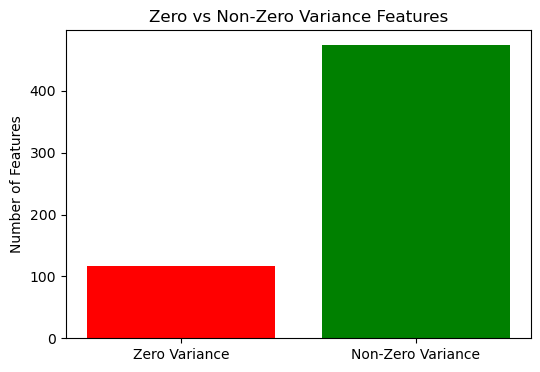

In [10]:
# Step 9: Plot a simple bar chart
plt.figure(figsize=(6, 4))
plt.bar(['Zero Variance', 'Non-Zero Variance'], 
        [zero_variance_count, nonzero_variance_count], 
        color=['red', 'green'])
plt.title('Zero vs Non-Zero Variance Features')
plt.ylabel('Number of Features')
plt.show()


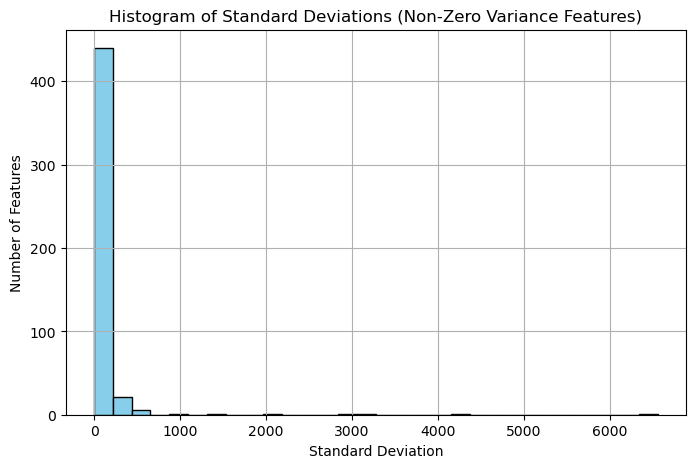

In [11]:
# Step 1: Filter only non-zero variance features
nonzero_variance_features = feature_std[feature_std != 0]

# Step 2: Plot full histogram of standard deviations
plt.figure(figsize=(8, 5))
plt.hist(nonzero_variance_features, bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Standard Deviations (Non-Zero Variance Features)')
plt.xlabel('Standard Deviation')
plt.ylabel('Number of Features')
plt.grid(True)
plt.show()

In [12]:
# Step 1: Sort the non-zero variance features by standard deviation (ascending)
sorted_std = nonzero_variance_features.sort_values()

In [13]:

# Step 2: Select the lowest 20 features
lowest_20_features = sorted_std.head(20)


In [14]:
# Step 3: Calculate cumulative percentage for Pareto chart
cumulative_percentage = lowest_20_features.cumsum() / lowest_20_features.sum()

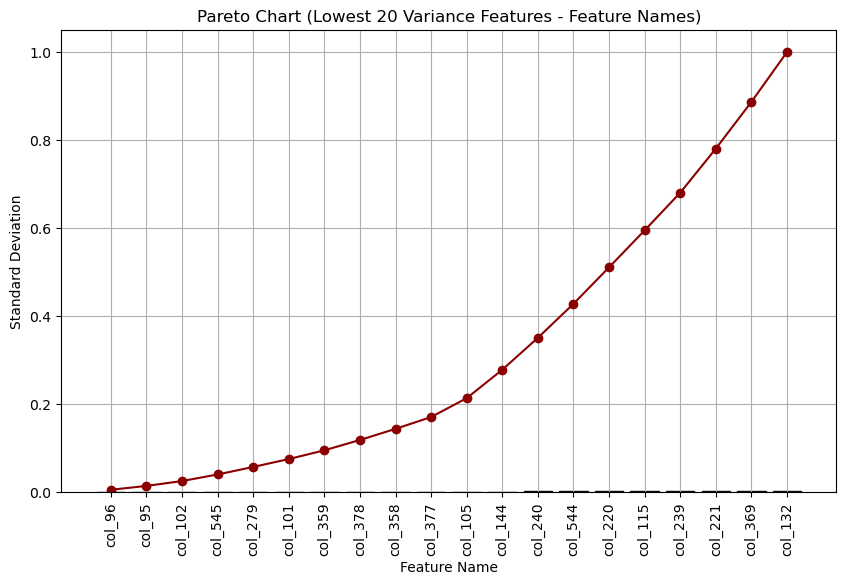

In [15]:
# Step 4: Plot with Feature Names on x-axis
plt.figure(figsize=(10, 6))
plt.bar(lowest_20_features.index, lowest_20_features.values, color='lightcoral', edgecolor='black')
plt.plot(lowest_20_features.index, cumulative_percentage, color='darkred', marker='o')
plt.title('Pareto Chart (Lowest 20 Variance Features - Feature Names)')
plt.xlabel('Feature Name')
plt.ylabel('Standard Deviation')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

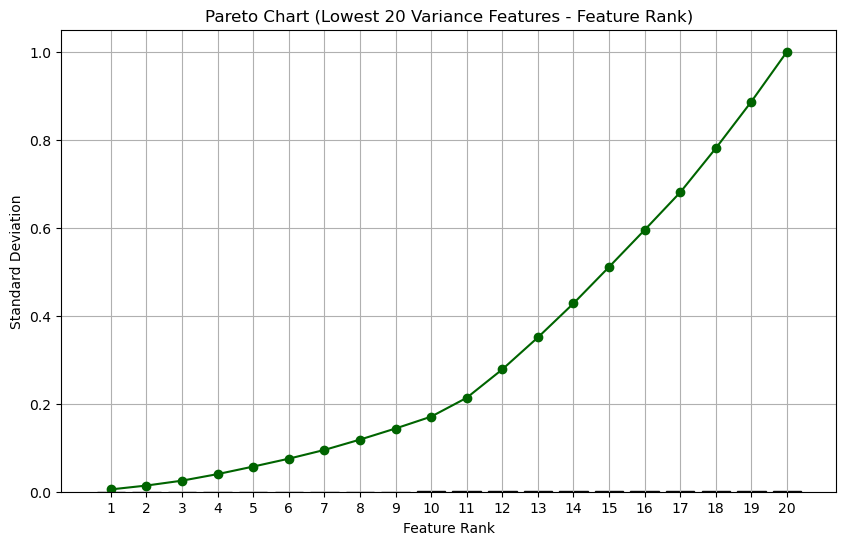

In [16]:
# Step 5: Plot with Feature Rank on x-axis
plt.figure(figsize=(10, 6))
plt.bar(range(1, 21), lowest_20_features.values, color='lightgreen', edgecolor='black')
plt.plot(range(1, 21), cumulative_percentage, color='darkgreen', marker='o')
plt.title('Pareto Chart (Lowest 20 Variance Features - Feature Rank)')
plt.xlabel('Feature Rank')
plt.ylabel('Standard Deviation')
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()

In [17]:
# Step 1: Calculate number of missing values per feature
missing_counts = data.isna().sum()
missing_counts

col_1       6
col_2       7
col_3      14
col_4      14
col_5      14
           ..
col_586     1
col_587     1
col_588     1
col_589     1
col_590     1
Length: 590, dtype: int64

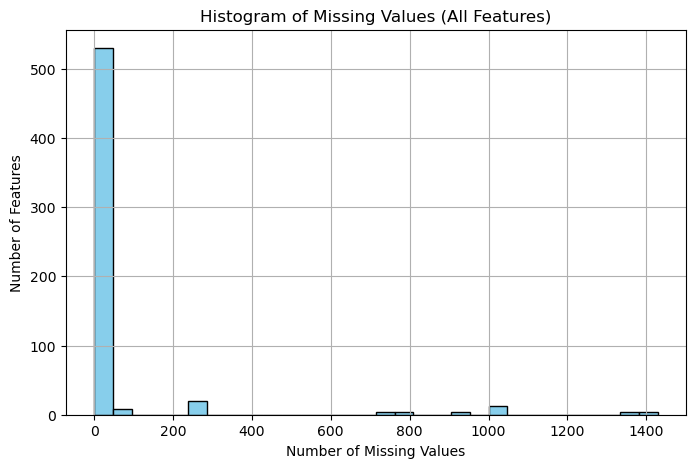

In [18]:
# Step 2: Plot 1 - Histogram including all features (even zero missing)
plt.figure(figsize=(8, 5))
plt.hist(missing_counts, bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Missing Values (All Features)')
plt.xlabel('Number of Missing Values')
plt.ylabel('Number of Features')
plt.grid(True)
plt.show()

In [19]:
# Step 3: Filter only features with at least 1 missing value
missing_counts_nonzero = missing_counts[missing_counts > 0]
missing_counts_nonzero

col_1       6
col_2       7
col_3      14
col_4      14
col_5      14
           ..
col_586     1
col_587     1
col_588     1
col_589     1
col_590     1
Length: 538, dtype: int64

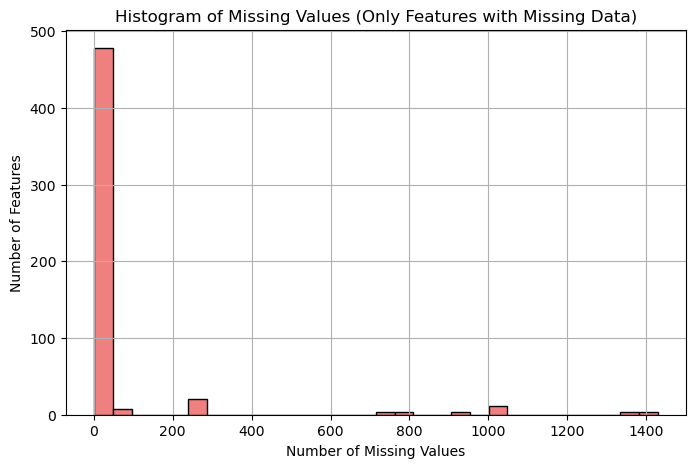

In [20]:
# Step 4: Plot 2 - Histogram of only features that have missing values
plt.figure(figsize=(8, 5))
plt.hist(missing_counts_nonzero, bins=30, color='lightcoral', edgecolor='black')
plt.title('Histogram of Missing Values (Only Features with Missing Data)')
plt.xlabel('Number of Missing Values')
plt.ylabel('Number of Features')
plt.grid(True)
plt.show()

In [21]:
# Step 1: Calculate missing counts and missing percentages
missing_counts = data.isna().sum()
missing_percentage = (missing_counts / data.shape[0]) * 100  # 1567 rows

# Step 2: Basic counts
num_features_total = data.shape[1]
num_features_no_missing = (missing_counts == 0).sum()
num_features_some_missing = (missing_counts > 0).sum()
num_features_half_missing = (missing_percentage > 50).sum()

print(f"Total features: {num_features_total}")
print(f"Features with NO missing values: {num_features_no_missing}")
print(f"Features with SOME missing values: {num_features_some_missing}")
print(f"Features with >50% missing values: {num_features_half_missing}")

# Step 3: Summary statistics
print("\nSummary of Missing Percentage:")
print(f"Minimum missing %: {missing_percentage.min():.2f}%")
print(f"Maximum missing %: {missing_percentage.max():.2f}%")
print(f"Mean missing %: {missing_percentage.mean():.2f}%")
print(f"Median missing %: {missing_percentage.median():.2f}%")

# Step 4: Top 10 features with most missingness
top_missing_features = missing_percentage.sort_values(ascending=False).head(10)
print("\nTop 10 features with highest missingness:")
print(top_missing_features)


Total features: 590
Features with NO missing values: 52
Features with SOME missing values: 538
Features with >50% missing values: 28

Summary of Missing Percentage:
Minimum missing %: 0.00%
Maximum missing %: 91.19%
Mean missing %: 4.54%
Median missing %: 0.38%

Top 10 features with highest missingness:
col_158    91.193363
col_293    91.193363
col_294    91.193363
col_159    91.193363
col_493    85.577537
col_359    85.577537
col_86     85.577537
col_221    85.577537
col_247    64.964901
col_110    64.964901
dtype: float64


Number of features with >50% missing values: 28


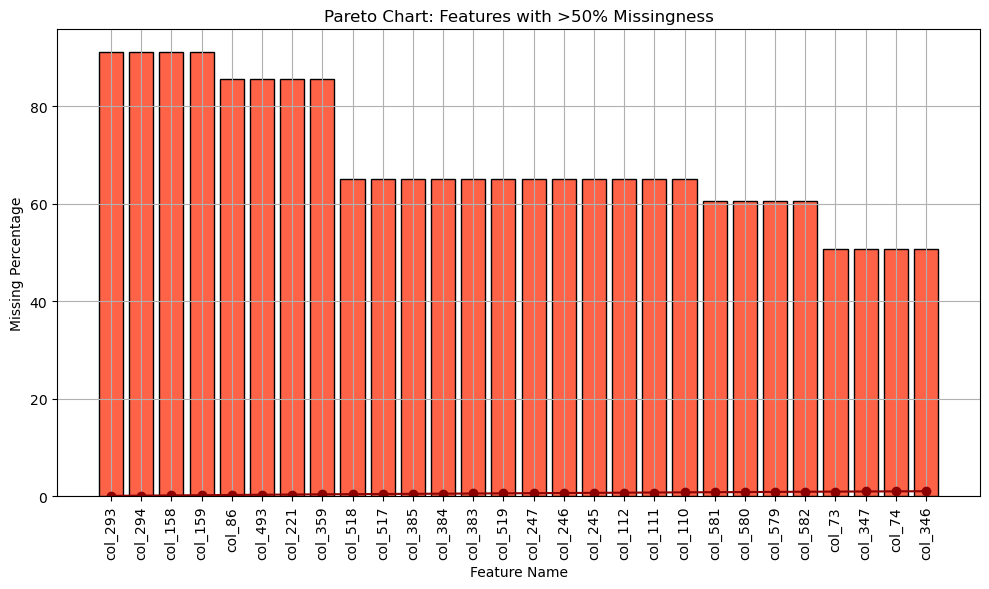


Summary Table: Features with >50% Missing Values


,Missing Count,Missing Percentage
col_293,1429,91.193363
col_294,1429,91.193363
col_158,1429,91.193363
col_159,1429,91.193363
col_86,1341,85.577537
col_493,1341,85.577537
col_221,1341,85.577537
col_359,1341,85.577537
col_518,1018,64.964901
col_517,1018,64.964901


In [22]:
# Step 1: Extract features with >50% missingness
bad_features = missing_percentage[missing_percentage > 50]

print(f"Number of features with >50% missing values: {bad_features.shape[0]}")

# Step 2: Sort them by missing percentage (descending)
bad_features_sorted = bad_features.sort_values(ascending=False)

# Step 3: Create a cumulative percentage for Pareto chart
cumulative_bad_percentage = bad_features_sorted.cumsum() / bad_features_sorted.sum()

# Step 4: Plot Pareto Chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(bad_features_sorted.index, bad_features_sorted.values, color='tomato', edgecolor='black')
plt.plot(bad_features_sorted.index, cumulative_bad_percentage, color='darkred', marker='o')
plt.title('Pareto Chart: Features with >50% Missingness')
plt.xlabel('Feature Name')
plt.ylabel('Missing Percentage')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 5: Create Summary Table
summary_table = pd.DataFrame({
    'Missing Count': missing_counts[bad_features_sorted.index],
    'Missing Percentage': bad_features_sorted
})

print("\nSummary Table: Features with >50% Missing Values")
display(summary_table)


In [23]:
# Step 1: Select only features with NO missing values
clean_features = missing_counts[missing_counts == 0].index
correlation_data_clean = data[clean_features]

# Step 2: Calculate correlation matrix
correlation_matrix_clean = correlation_data_clean.corr(method='pearson')  # standard linear correlation

# Step 3: Show basic info
print(f"Shape of correlation matrix: {correlation_matrix_clean.shape}")

# Step 4: Show quick stats (min, max, mean of correlation values)
import numpy as np

# Remove self-correlations (diagonal) by masking them
mask = ~np.eye(correlation_matrix_clean.shape[0], dtype=bool)
correlation_values = correlation_matrix_clean.values[mask]

print(f"Minimum correlation value (excluding diagonal): {correlation_values.min():.4f}")
print(f"Maximum correlation value (excluding diagonal): {correlation_values.max():.4f}")
print(f"Mean correlation value (excluding diagonal): {correlation_values.mean():.4f}")


Shape of correlation matrix: (52, 52)
Minimum correlation value (excluding diagonal): -0.8140
Maximum correlation value (excluding diagonal): 1.0000
Mean correlation value (excluding diagonal): 0.0433


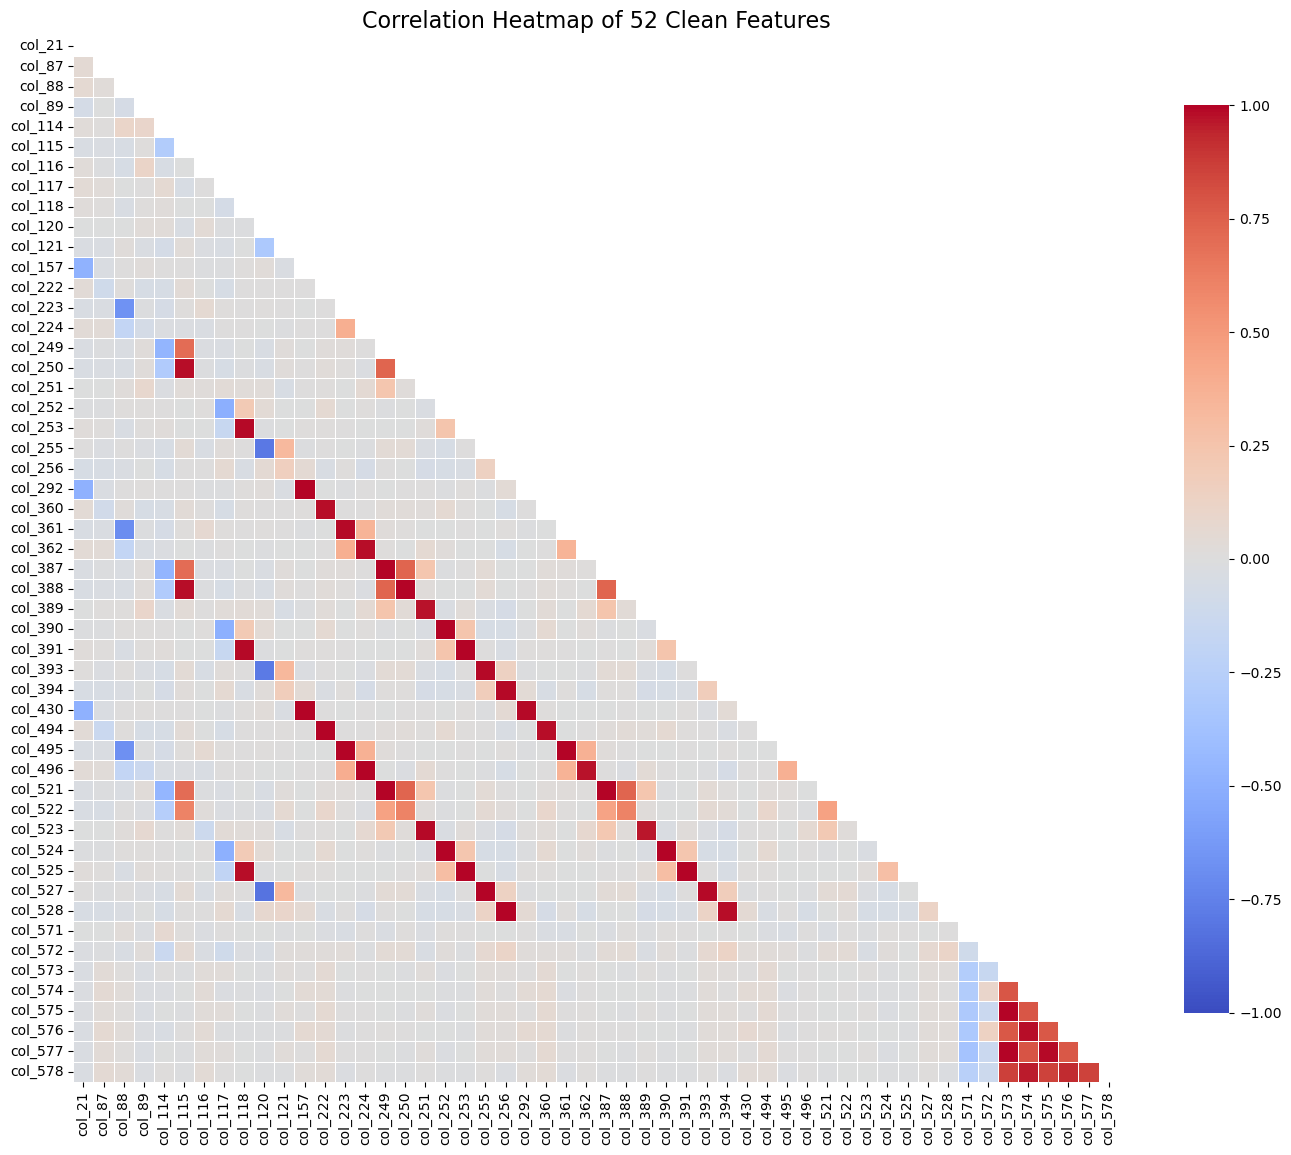

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 1: Prepare mask to hide upper triangle
mask = np.triu(np.ones_like(correlation_matrix_clean, dtype=bool))

# Step 2: Set figure size
plt.figure(figsize=(14, 12))

# Step 3: Create heatmap
sns.heatmap(
    correlation_matrix_clean, 
    mask=mask, 
    cmap='coolwarm',   # Blue to red color scheme
    vmax=1.0, vmin=-1.0,  # Set range of colors
    center=0, 
    square=True, 
    linewidths=0.5, 
    cbar_kws={"shrink": 0.8},
    annot=False  # You can set True if you want to see correlation numbers
)

# Step 4: Title and final touches
plt.title('Correlation Heatmap of 52 Clean Features', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [25]:

# Step 1: Remove self-correlation by setting diagonal to NaN
corr_matrix_no_diag = correlation_matrix_clean.copy()
np.fill_diagonal(corr_matrix_no_diag.values, np.nan)

# Step 2: Flatten the matrix
corr_pairs = corr_matrix_no_diag.unstack()

# Step 3: Drop NaN pairs
corr_pairs = corr_pairs.dropna()

# Step 4: Filter only strong correlations (above 0.8 or below -0.8)
strong_corr_pairs = corr_pairs[(corr_pairs >= 0.8) | (corr_pairs <= -0.8)]

# Step 5: Sort them nicely
strong_corr_pairs = strong_corr_pairs.sort_values(ascending=False)

# Step 6: Display
print(f"Number of strongly correlated feature pairs: {strong_corr_pairs.shape[0]}")
print("\nStrongly Correlated Features (|correlation| >= 0.8):")
print(strong_corr_pairs)



Number of strongly correlated feature pairs: 92

Strongly Correlated Features (|correlation| >= 0.8):
col_391  col_253    0.999991
col_253  col_391    0.999991
col_390  col_252    0.999939
col_252  col_390    0.999939
col_250  col_388    0.999938
                      ...   
col_577  col_578    0.859278
col_578  col_575    0.851784
col_575  col_578    0.851784
col_120  col_527   -0.813955
col_527  col_120   -0.813955
Length: 92, dtype: float64


In [26]:
# Step 1: Prepare
outlier_summary = {}

# Step 2: Analyze each feature one by one
for col in correlation_data_clean.columns:
    feature_data = correlation_data_clean[col]
    
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = feature_data.quantile(0.25)
    Q3 = feature_data.quantile(0.75)
    IQR = Q3 - Q1
    
    # Define outlier thresholds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Find outliers
    outliers = feature_data[(feature_data < lower_bound) | (feature_data > upper_bound)]
    
    # Store results
    outlier_summary[col] = {
        'Total Rows': feature_data.shape[0],
        'Outlier Count': outliers.shape[0],
        'Outlier Percentage': (outliers.shape[0] / feature_data.shape[0]) * 100
    }

# Step 3: Convert summary into a DataFrame
import pandas as pd

outlier_summary_df = pd.DataFrame(outlier_summary).T
outlier_summary_df = outlier_summary_df.sort_values(by='Outlier Percentage', ascending=False)

# Step 4: Display
print("Summary of Outliers per Feature (using IQR Method):")
print(outlier_summary_df)


Summary of Outliers per Feature (using IQR Method):
         Total Rows  Outlier Count  Outlier Percentage
col_252      1567.0          201.0           12.827058
col_524      1567.0          199.0           12.699426
col_117      1567.0          192.0           12.252712
col_390      1567.0          189.0           12.061264
col_495      1567.0          144.0            9.189534
col_223      1567.0          138.0            8.806637
col_361      1567.0          136.0            8.679004
col_574      1567.0          103.0            6.573070
col_576      1567.0           95.0            6.062540
col_571      1567.0           94.0            5.998724
col_578      1567.0           92.0            5.871091
col_577      1567.0           88.0            5.615826
col_573      1567.0           87.0            5.552010
col_575      1567.0           86.0            5.488194
col_118      1567.0           80.0            5.105297
col_157      1567.0           65.0            4.148054
col_430      

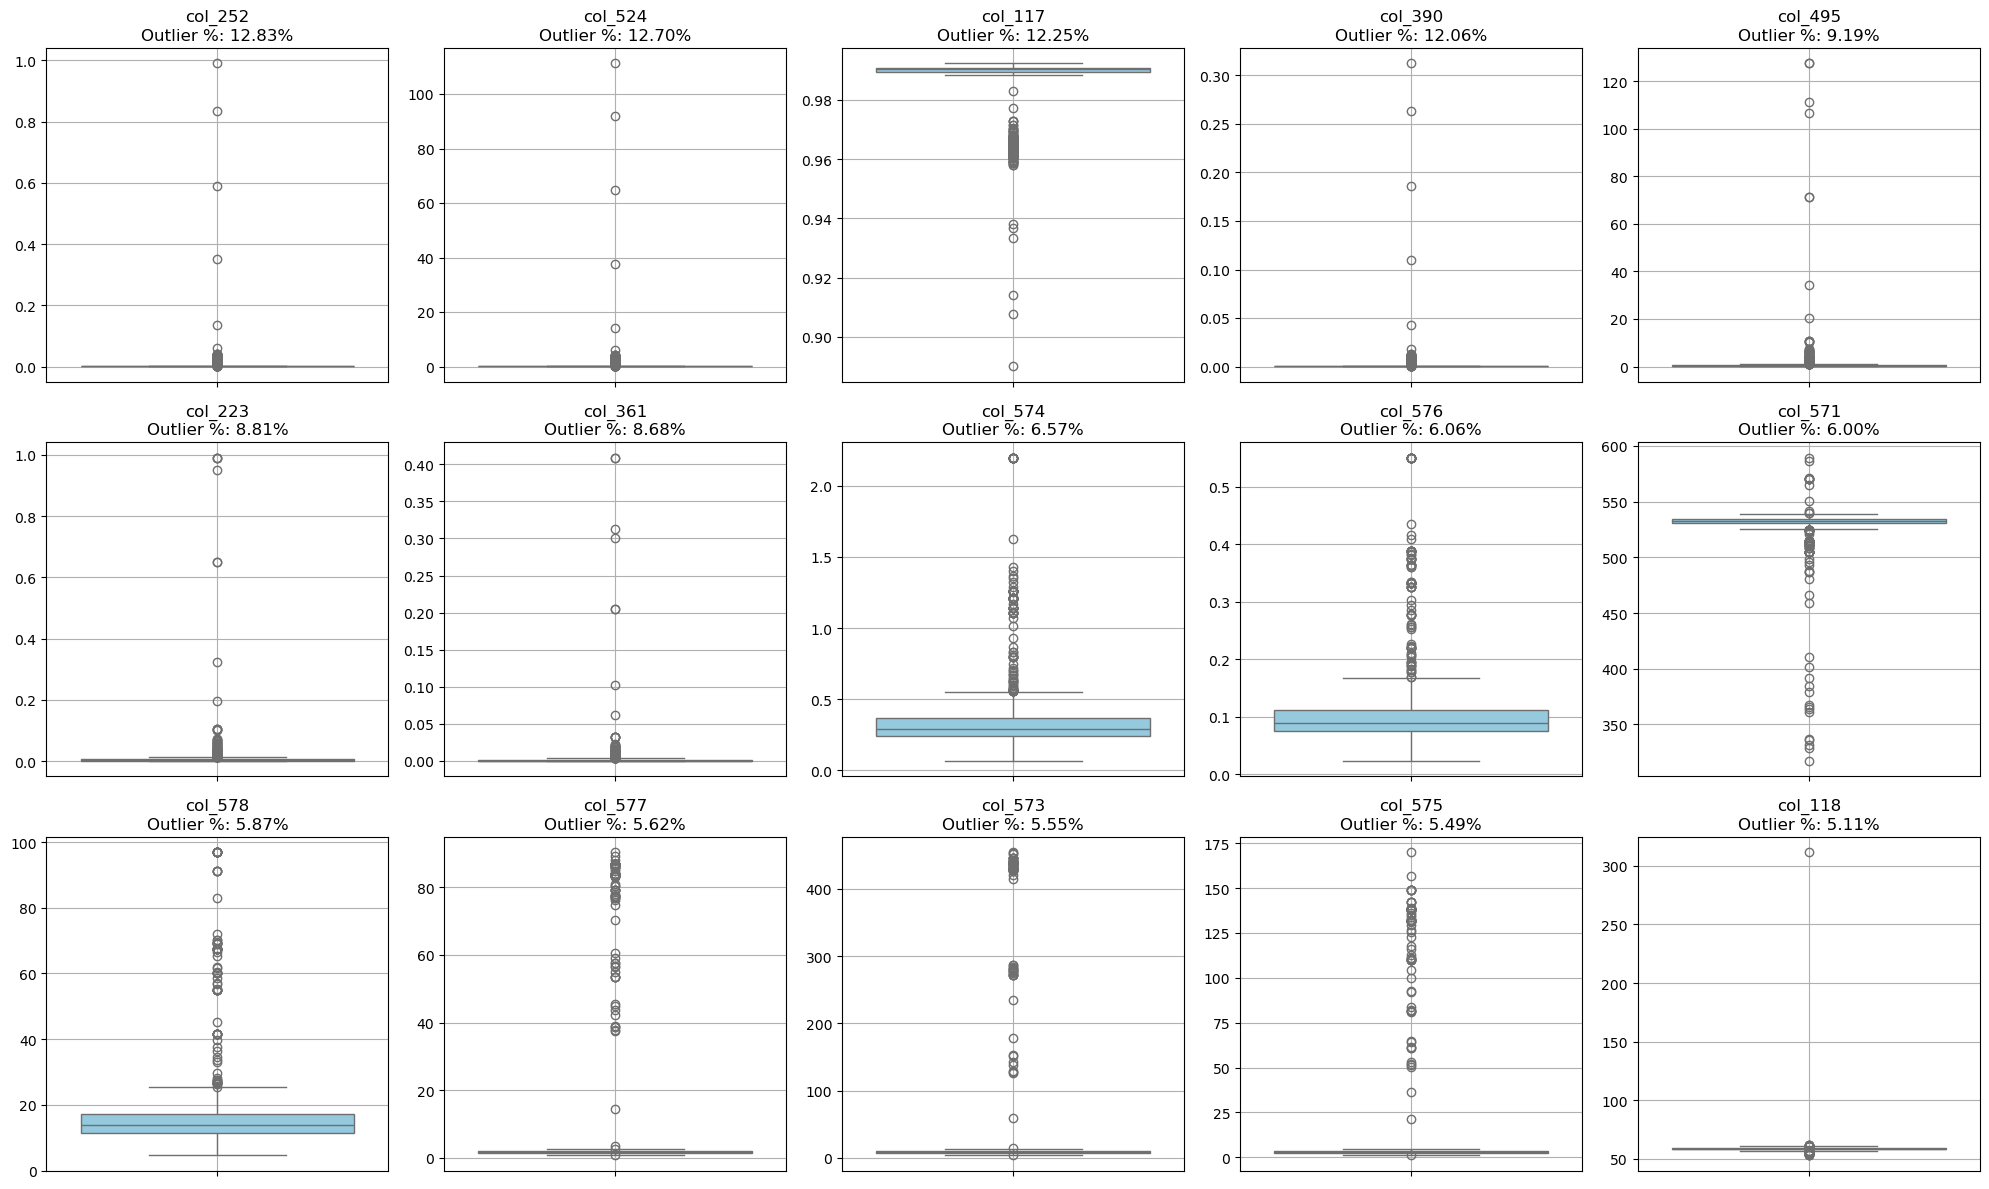

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Select features with >5% outliers
features_over_5pct = outlier_summary_df[outlier_summary_df['Outlier Percentage'] > 5].index.tolist()

# Step 2: Set up plot grid
num_features = len(features_over_5pct)
plots_per_row = 5
num_rows = (num_features + plots_per_row - 1) // plots_per_row  # ceiling division

# Step 3: Create figure
fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(20, num_rows * 4))  # Bigger size for clarity
axes = axes.flatten()  # Flatten axes array for easy indexing

# Step 4: Plot each feature
for idx, feature in enumerate(features_over_5pct):
    sns.boxplot(
        y=correlation_data_clean[feature], 
        ax=axes[idx], 
        color="skyblue"
    )
    axes[idx].set_title(f'{feature}\nOutlier %: {outlier_summary_df.loc[feature, "Outlier Percentage"]:.2f}%')
    axes[idx].set_ylabel('')
    axes[idx].grid(True)

# Step 5: Hide unused subplots
for idx in range(num_features, len(axes)):
    fig.delaxes(axes[idx])

# Step 6: Final adjustments
plt.tight_layout()
plt.show()


In [28]:
# Step 1: Calculate missing values count per feature
missing_counts_per_feature = data.isna().sum()

# Step 2: Calculate missing percentage per feature
missing_percentage_per_feature = (missing_counts_per_feature / data.shape[0]) * 100

# Step 3: Combine into a clean table
missingness_table = pd.DataFrame({
    'Missing Count': missing_counts_per_feature,
    'Missing Percentage': missing_percentage_per_feature
})

# Step 4: Sort descending to see worst ones first
missingness_table = missingness_table.sort_values(by='Missing Percentage', ascending=False)

# Step 5: Show result
print("Missingness Summary (per feature):")
print(missingness_table)


Missingness Summary (per feature):
         Missing Count  Missing Percentage
col_158           1429           91.193363
col_293           1429           91.193363
col_294           1429           91.193363
col_159           1429           91.193363
col_493           1341           85.577537
...                ...                 ...
col_252              0            0.000000
col_253              0            0.000000
col_255              0            0.000000
col_256              0            0.000000
col_388              0            0.000000

[590 rows x 2 columns]


In [29]:
# Just show Feature name and Missing Percentage, sorted descending
missingness_clean_view = missingness_table[['Missing Percentage']]

# Sort from highest missingness to lowest
missingness_clean_view = missingness_clean_view.sort_values(by='Missing Percentage', ascending=False)

# Display
print("Missing Percentage per Feature:")
print(missingness_clean_view)


Missing Percentage per Feature:
         Missing Percentage
col_158           91.193363
col_159           91.193363
col_293           91.193363
col_294           91.193363
col_359           85.577537
...                     ...
col_117            0.000000
col_118            0.000000
col_120            0.000000
col_121            0.000000
col_388            0.000000

[590 rows x 1 columns]


In [30]:
# Step 1: Select features with ≤2% missingness
selected_features = missingness_table[missingness_table['Missing Percentage'] <= 2].index
data_selected = data[selected_features]

# Step 2: Calculate the correlation matrix
correlation_matrix_selected = data_selected.corr(method='pearson')

# Step 3: Print basic info
print(f"Number of features selected: {len(selected_features)}")
print(f"Shape of correlation matrix: {correlation_matrix_selected.shape}")

# Step 4: Quick statistics on correlations
import numpy as np

# Mask the diagonal (self-correlation)
mask = ~np.eye(correlation_matrix_selected.shape[0], dtype=bool)
correlation_values = correlation_matrix_selected.values[mask]

print(f"Minimum correlation value (excluding diagonal): {correlation_values.min():.4f}")
print(f"Maximum correlation value (excluding diagonal): {correlation_values.max():.4f}")
print(f"Mean correlation value (excluding diagonal): {correlation_values.mean():.4f}")


Number of features selected: 530
Shape of correlation matrix: (530, 530)
Minimum correlation value (excluding diagonal): nan
Maximum correlation value (excluding diagonal): nan
Mean correlation value (excluding diagonal): nan


In [31]:
# Step 0: Recalculate missing counts and percentages
missing_counts = data.isna().sum()
missing_percentages = (missing_counts / data.shape[0]) * 100

# Step 1: Select features with <18% missingness
features_under_18_missing = missing_percentages[missing_percentages < 18].index
data_under_18_missing = data[features_under_18_missing]

# Step 2: Prepare IQR and Z-score quick exploration
import numpy as np

iqr_multipliers = [1.2, 1.5, 2.0]
zscore_thresholds = [2.0, 2.5, 3.0]

iqr_results = {}
zscore_results = {}

# IQR-based outliers
for mult in iqr_multipliers:
    outlier_counts = []
    for col in data_under_18_missing.columns:
        col_data = data_under_18_missing[col].dropna()
        Q1 = col_data.quantile(0.25)
        Q3 = col_data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - mult * IQR
        upper_bound = Q3 + mult * IQR
        outliers = ((col_data < lower_bound) | (col_data > upper_bound)).sum()
        outlier_percentage = (outliers / len(col_data)) * 100
        outlier_counts.append(outlier_percentage)
    iqr_results[mult] = {
        'mean_outlier_percent': np.mean(outlier_counts),
        'min_outlier_percent': np.min(outlier_counts),
        'max_outlier_percent': np.max(outlier_counts)
    }

# Z-score-based outliers
for thresh in zscore_thresholds:
    outlier_counts = []
    for col in data_under_18_missing.columns:
        col_data = data_under_18_missing[col].dropna()
        z_scores = (col_data - col_data.mean()) / col_data.std()
        outliers = (np.abs(z_scores) > thresh).sum()
        outlier_percentage = (outliers / len(col_data)) * 100
        outlier_counts.append(outlier_percentage)
    zscore_results[thresh] = {
        'mean_outlier_percent': np.mean(outlier_counts),
        'min_outlier_percent': np.min(outlier_counts),
        'max_outlier_percent': np.max(outlier_counts)
    }

# Step 3: Show results nicely
import pandas as pd

iqr_df = pd.DataFrame(iqr_results).T
zscore_df = pd.DataFrame(zscore_results).T

print("\nIQR-Based Outlier Summary:")
print(iqr_df)

print("\nZ-Score-Based Outlier Summary:")
print(zscore_df)



IQR-Based Outlier Summary:
     mean_outlier_percent  min_outlier_percent  max_outlier_percent
1.2              3.909340                  0.0            22.747604
1.5              2.708783                  0.0            22.619808
2.0              1.707307                  0.0            22.619808

Z-Score-Based Outlier Summary:
     mean_outlier_percent  min_outlier_percent  max_outlier_percent
2.0              2.360886                  0.0            14.841218
2.5              1.136025                  0.0             4.980843
3.0              0.687683                  0.0             4.533844


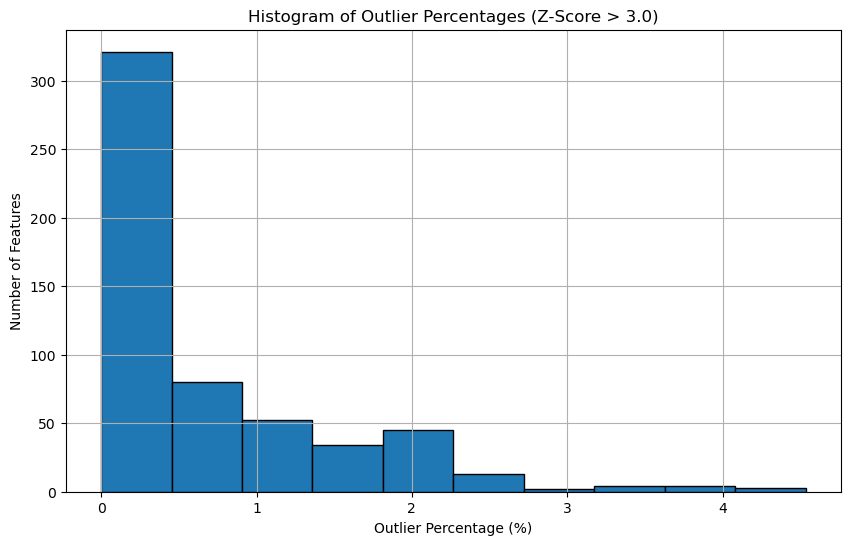

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Calculate Z-Scores for features with <18% missingness
from scipy.stats import zscore

# Step 2: Calculate Outlier Percentages per feature
outlier_percentages = []

for col in data_under_18_missing.columns:
    col_data = data_under_18_missing[col].dropna()
    z_scores = (col_data - col_data.mean()) / col_data.std()
    outliers = (np.abs(z_scores) > 3.0).sum()
    outlier_percentage = (outliers / len(col_data)) * 100
    outlier_percentages.append(outlier_percentage)

# Step 3: Plot Histogram
plt.figure(figsize=(10,6))
plt.hist(outlier_percentages, bins=10, edgecolor='black')
plt.title('Histogram of Outlier Percentages (Z-Score > 3.0)')
plt.xlabel('Outlier Percentage (%)')
plt.ylabel('Number of Features')
plt.grid(True)
plt.show()


In [33]:
# Step 1: Merge Features and Label
merged_data = data.copy()
merged_data['label'] = labels['label'].values  # Merge based on row order

# Step 2: Stratified split
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(
    merged_data,
    test_size=0.2,
    stratify=merged_data['label'],
    random_state=42
)

# Step 3: Count distribution
full_counts = merged_data['label'].value_counts().sort_index()
train_counts = train_data['label'].value_counts().sort_index()
test_counts = test_data['label'].value_counts().sort_index()

# Step 4: Create the table
import pandas as pd

distribution_table = pd.DataFrame({
    'Full Data': full_counts,
    'Train Data': train_counts,
    'Test Data': test_counts
})


In [34]:
labels


,label,timestamp
0,-1,19/07/2008 11:55:00
1,-1,19/07/2008 12:32:00
2,1,19/07/2008 13:17:00
3,-1,19/07/2008 14:43:00
4,-1,19/07/2008 15:22:00
...,...,...
1562,-1,16/10/2008 15:13:00
1563,-1,16/10/2008 20:49:00
1564,-1,17/10/2008 05:26:00
1565,-1,17/10/2008 06:01:00


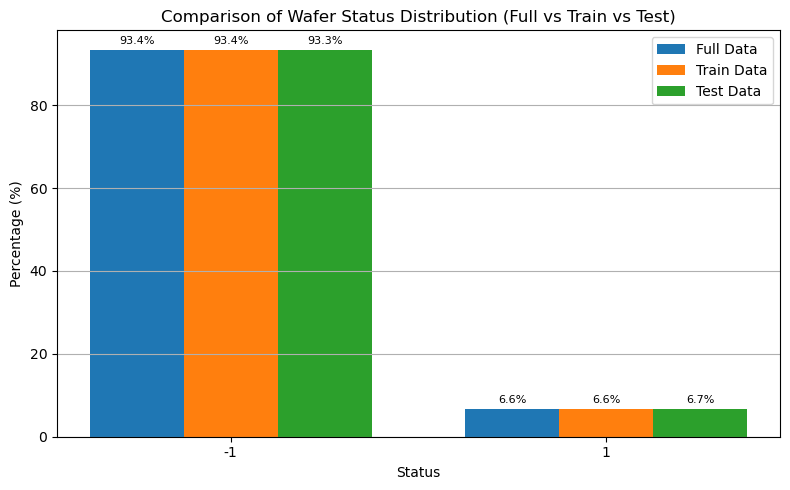

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate total counts for percentages
full_total = distribution_table['Full Data'].sum()
train_total = distribution_table['Train Data'].sum()
test_total = distribution_table['Test Data'].sum()

# Create percentage tables
distribution_percentage = pd.DataFrame({
    'Full Data': (distribution_table['Full Data'] / full_total) * 100,
    'Train Data': (distribution_table['Train Data'] / train_total) * 100,
    'Test Data': (distribution_table['Test Data'] / test_total) * 100
})

labels_list = distribution_percentage.index.tolist()
x = np.arange(len(labels_list))  # the label locations
width = 0.25  # width of the bars

fig, ax = plt.subplots(figsize=(8,5))
rects1 = ax.bar(x - width, distribution_percentage['Full Data'], width, label='Full Data')
rects2 = ax.bar(x, distribution_percentage['Train Data'], width, label='Train Data')
rects3 = ax.bar(x + width, distribution_percentage['Test Data'], width, label='Test Data')

# Add text for labels, title and custom x-axis tick labels
ax.set_ylabel('Percentage (%)')
ax.set_title('Comparison of Wafer Status Distribution (Full vs Train vs Test)')
ax.set_xticks(x)
ax.set_xticklabels(labels_list)
ax.set_xlabel('Status')
ax.legend()
plt.grid(True, axis='y')
plt.tight_layout()

# Function to attach a text label above each bar
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

# Apply the label function to each set of bars
add_labels(rects1)
add_labels(rects2)
add_labels(rects3)

plt.show()


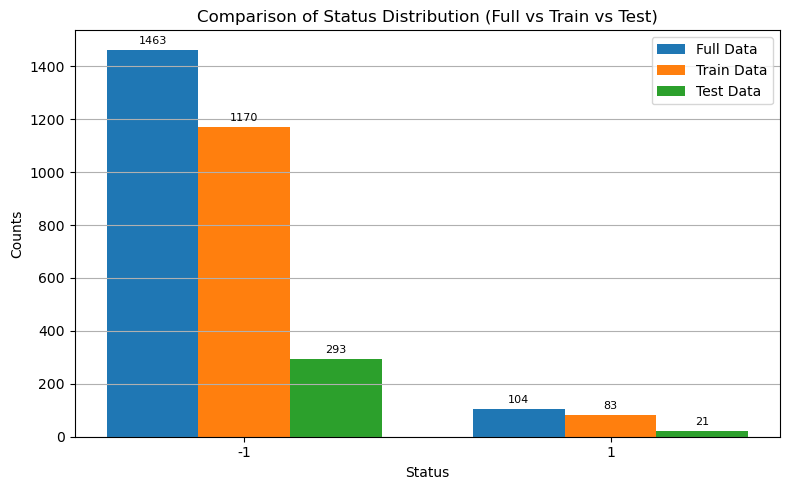

In [36]:
import matplotlib.pyplot as plt
import numpy as np

labels_list = distribution_table.index.tolist()
x = np.arange(len(labels_list))  # the label locations

width = 0.25  # width of the bars

fig, ax = plt.subplots(figsize=(8,5))
rects1 = ax.bar(x - width, distribution_table['Full Data'], width, label='Full Data')
rects2 = ax.bar(x, distribution_table['Train Data'], width, label='Train Data')
rects3 = ax.bar(x + width, distribution_table['Test Data'], width, label='Test Data')

# Add text for labels, title and custom x-axis tick labels
ax.set_ylabel('Counts')
ax.set_xlabel('Status')  # <-- THIS is what you were missing
ax.set_title('Comparison of Status Distribution (Full vs Train vs Test)')
ax.set_xticks(x)
ax.set_xticklabels(labels_list)
ax.legend()
plt.grid(True, axis='y')
plt.tight_layout()

# Function to attach a text label above each bar
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate('{}'.format(height),
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

# Apply the label function to each set of bars
add_labels(rects1)
add_labels(rects2)
add_labels(rects3)

plt.show()


In [37]:
# Step 1: Drop the label column to only keep features
full_features = merged_data.drop(columns=['label'])
train_features = train_data.drop(columns=['label'])
test_features = test_data.drop(columns=['label'])

# Step 2: Calculate standard deviation (volatility) for each feature
full_std = full_features.std()
train_std = train_features.std()
test_std = test_features.std()

# Step 3: Sum of standard deviations (total volatility)
full_total_volatility = full_std.sum()
train_total_volatility = train_std.sum()
test_total_volatility = test_std.sum()

# Step 4: Calculate percentage volatility relative to Full Data
train_volatility_percentage = (train_total_volatility / full_total_volatility) * 100
test_volatility_percentage = (test_total_volatility / full_total_volatility) * 100

# Step 5: Summarize Results
summary = {
    "Full Data Volatility Sum": full_total_volatility,
    "Train Data Volatility Sum": train_total_volatility,
    "Test Data Volatility Sum": test_total_volatility,
    "Train Volatility % of Full": train_volatility_percentage,
    "Test Volatility % of Full": test_volatility_percentage
}

# Step 6: Display the summary
for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.2f}")
    else:
        print(f"{key}: {value}")


Full Data Volatility Sum: 34756.35
Train Data Volatility Sum: 34722.92
Test Data Volatility Sum: 33791.59
Train Volatility % of Full: 99.90
Test Volatility % of Full: 97.22


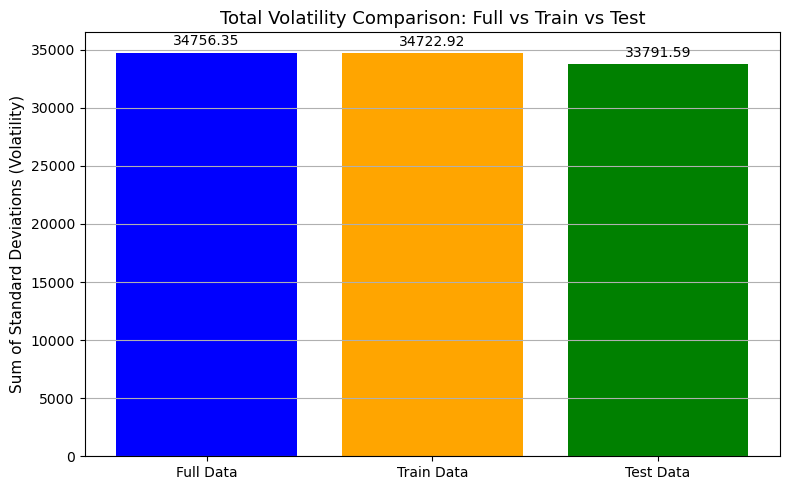

In [38]:
import matplotlib.pyplot as plt

# Step 1: Labels and Values
labels = ['Full Data', 'Train Data', 'Test Data']
volatility_values = [full_total_volatility, train_total_volatility, test_total_volatility]

# Step 2: Bar Plot
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, volatility_values, color=['blue', 'orange', 'green'])

# Step 3: Annotate raw values on top of bars
for bar, value in zip(bars, volatility_values):
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',   # show 2 decimal places
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3-point vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Step 4: Labels and Grid
ax.set_ylabel('Sum of Standard Deviations (Volatility)', fontsize=11)
ax.set_title('Total Volatility Comparison: Full vs Train vs Test', fontsize=13)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


In [39]:
# Step 1: Calculate total missing cells
full_missing_cells = merged_data.isnull().sum().sum()
train_missing_cells = train_data.isnull().sum().sum()
test_missing_cells = test_data.isnull().sum().sum()

# Step 2: Calculate percentage relative to full data
train_missing_percent = (train_missing_cells / full_missing_cells) * 100
test_missing_percent = (test_missing_cells / full_missing_cells) * 100

# Step 3: Print results
print(f"📊 Full Data Missing Cells: {full_missing_cells}")
print(f"📈 Train Data Missing Cells: {train_missing_cells}")
print(f"📉 Test Data Missing Cells: {test_missing_cells}")

print(f"\n✅ Train Missingness % of Full: {train_missing_percent:.2f}%")
print(f"✅ Test Missingness % of Full: {test_missing_percent:.2f}%")


📊 Full Data Missing Cells: 41951
📈 Train Data Missing Cells: 33868
📉 Test Data Missing Cells: 8083

✅ Train Missingness % of Full: 80.73%
✅ Test Missingness % of Full: 19.27%


In [40]:
# Average volatility = total volatility / number of features
avg_full_volatility = full_total_volatility / full_features.shape[1]
avg_train_volatility = train_total_volatility / train_features.shape[1]
avg_test_volatility = test_total_volatility / test_features.shape[1]


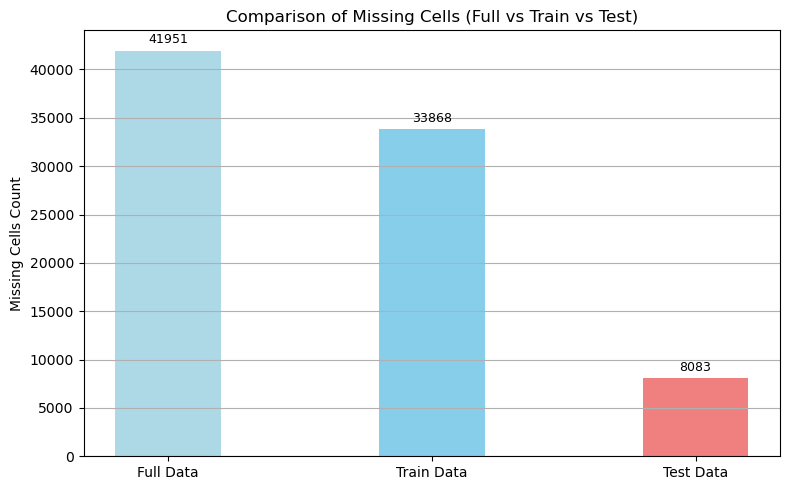

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Values you already have
full_missing_cells = 41951
train_missing_cells = 33868
test_missing_cells = 8083

# Prepare data
labels_list = ['Full Data', 'Train Data', 'Test Data']
values = [full_missing_cells, train_missing_cells, test_missing_cells]
x = np.arange(len(labels_list))  # the label locations
width = 0.4  # width of the bars

# Create bar plot
fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(x, values, width, color=['lightblue', 'skyblue', 'lightcoral'])

# Add text labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate('{}'.format(height),
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

# Set labels
ax.set_ylabel('Missing Cells Count')
ax.set_title('Comparison of Missing Cells (Full vs Train vs Test)')
ax.set_xticks(x)
ax.set_xticklabels(labels_list)
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()


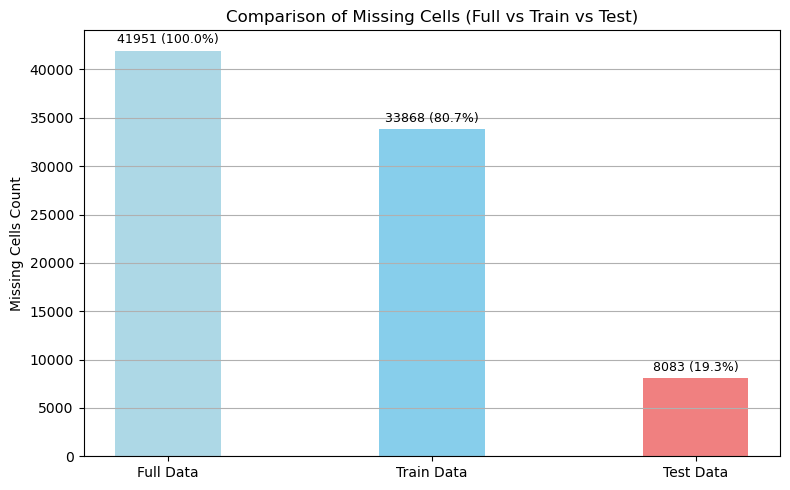

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Your known values
full_missing_cells = 41951
train_missing_cells = 33868
test_missing_cells = 8083

# Prepare data
labels_list = ['Full Data', 'Train Data', 'Test Data']
values = [full_missing_cells, train_missing_cells, test_missing_cells]
percentages = [
    100,  # Full data is baseline 100%
    (train_missing_cells / full_missing_cells) * 100,
    (test_missing_cells / full_missing_cells) * 100
]

x = np.arange(len(labels_list))  # label locations
width = 0.4  # width of bars

# Create bar plot
fig, ax = plt.subplots(figsize=(8,5))
colors = ['lightblue', 'skyblue', 'lightcoral']
bars = ax.bar(x, values, width, color=colors)

# Annotate with number and percentage
for bar, value, pct in zip(bars, values, percentages):
    height = bar.get_height()
    ax.annotate(f'{value} ({pct:.1f}%)',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

# Labels and Title
ax.set_ylabel('Missing Cells Count')
ax.set_title('Comparison of Missing Cells (Full vs Train vs Test)')
ax.set_xticks(x)
ax.set_xticklabels(labels_list)
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()


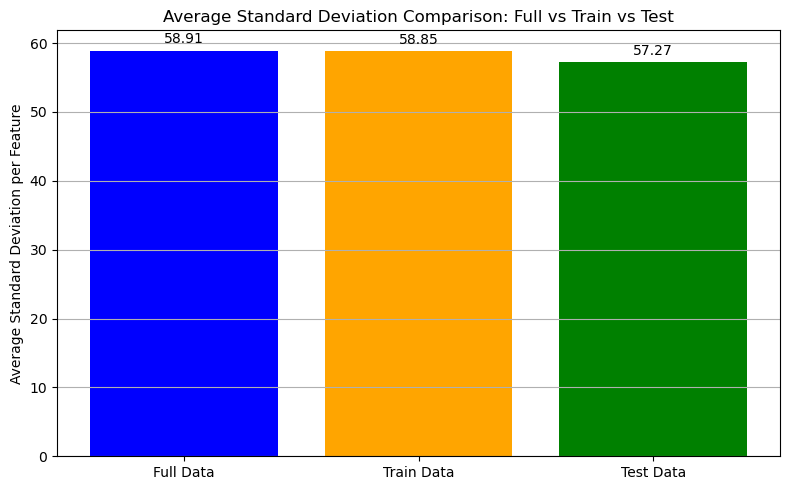

In [43]:
import matplotlib.pyplot as plt

# Step 1: Drop the label column from all datasets
full_features = merged_data.drop(columns=['label'])
train_features = train_data.drop(columns=['label'])
test_features = test_data.drop(columns=['label'])

# Step 2: Calculate standard deviation (volatility) per feature
full_std = full_features.std()
train_std = train_features.std()
test_std = test_features.std()

# Step 3: Calculate total and average volatility
full_total_volatility = full_std.sum()
train_total_volatility = train_std.sum()
test_total_volatility = test_std.sum()

# Average volatility (per feature)
avg_full_volatility = full_total_volatility / full_features.shape[1]
avg_train_volatility = train_total_volatility / train_features.shape[1]
avg_test_volatility = test_total_volatility / test_features.shape[1]

# Step 4: Plotting
labels = ['Full Data', 'Train Data', 'Test Data']
avg_volatilities = [avg_full_volatility, avg_train_volatility, avg_test_volatility]

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(labels, avg_volatilities, color=['blue', 'orange', 'green'])

# Add values on top of the bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Titles and labels
ax.set_ylabel('Average Standard Deviation per Feature')
ax.set_title('Average Standard Deviation Comparison: Full vs Train vs Test')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


In [44]:
# Step 1: Separate features and labels
X_train = train_data.drop(columns=['label'])
y_train = train_data['label']

# Step 2: Check for duplicated feature rows
duplicate_mask = X_train.duplicated()
num_duplicates = duplicate_mask.sum()

print(f"Total duplicated feature rows in training set: {num_duplicates}")
print(f"Percentage of duplicated feature rows: {100 * num_duplicates / X_train.shape[0]:.2f}%")


Total duplicated feature rows in training set: 0
Percentage of duplicated feature rows: 0.00%


In [45]:
# Step 1: Check zero volatility (ignoring NaNs)
zero_volatility_columns = []

for col in X_train.columns:
    # Drop NaNs, then check unique values
    if X_train[col].dropna().nunique() == 1:
        zero_volatility_columns.append(col)

# Step 2: Report results
print(f"Number of zero-volatility columns: {len(zero_volatility_columns)}")
print("Zero-volatility columns:")
print(zero_volatility_columns)

Number of zero-volatility columns: 116
Zero-volatility columns:
['col_6', 'col_14', 'col_43', 'col_50', 'col_53', 'col_70', 'col_98', 'col_142', 'col_150', 'col_179', 'col_180', 'col_187', 'col_190', 'col_191', 'col_192', 'col_193', 'col_194', 'col_195', 'col_227', 'col_230', 'col_231', 'col_232', 'col_233', 'col_234', 'col_235', 'col_236', 'col_237', 'col_238', 'col_241', 'col_242', 'col_243', 'col_244', 'col_257', 'col_258', 'col_259', 'col_260', 'col_261', 'col_262', 'col_263', 'col_264', 'col_265', 'col_266', 'col_267', 'col_277', 'col_285', 'col_314', 'col_315', 'col_316', 'col_323', 'col_326', 'col_327', 'col_328', 'col_329', 'col_330', 'col_331', 'col_365', 'col_370', 'col_371', 'col_372', 'col_373', 'col_374', 'col_375', 'col_376', 'col_379', 'col_380', 'col_381', 'col_382', 'col_395', 'col_396', 'col_397', 'col_398', 'col_399', 'col_400', 'col_401', 'col_402', 'col_403', 'col_404', 'col_405', 'col_415', 'col_423', 'col_450', 'col_451', 'col_452', 'col_459', 'col_462', 'col_463

In [46]:
# Step 1: Drop zero-volatility columns from X_train
X_train = X_train.drop(columns=zero_volatility_columns)

print(f"Shape of X_train after dropping zero-volatility columns: {X_train.shape}")


Shape of X_train after dropping zero-volatility columns: (1253, 474)


In [47]:
# Step 1: Calculate Standard Deviation for each column in X_train
pd.set_option('display.max_rows', None)
std_per_column = X_train.std(skipna=True)  # skip NaNs while calculating

# Step 2: Display results
print("\nStandard Deviation per Feature (Training Set):")
print(std_per_column.sort_values())



Standard Deviation per Feature (Training Set):
col_96        0.000105
col_95        0.000172
col_102       0.000215
col_545       0.000291
col_279       0.000339
col_101       0.000360
col_359       0.000363
col_378       0.000480
col_358       0.000501
col_377       0.000551
col_105       0.000816
col_144       0.001289
col_240       0.001488
col_544       0.001504
col_220       0.001659
col_221       0.001700
col_239       0.001741
col_115       0.001864
col_369       0.002100
col_132       0.002209
col_367       0.002401
col_366       0.002542
col_368       0.002580
col_543       0.002700
col_589       0.002758
col_581       0.002876
col_393       0.002958
col_86        0.002984
col_107       0.002991
col_104       0.003005
col_94        0.003016
col_289       0.003168
col_106       0.003263
col_93        0.003290
col_583       0.003449
col_585       0.004133
col_58        0.004218
col_85        0.005053
col_388       0.005577
col_282       0.005588
col_392       0.006414
col_57   

In [48]:
# Step 1: Sort the standard deviations in descending order
std_sorted = std_per_column.sort_values(ascending=False)

# Step 2: Calculate cumulative standard deviation percentage
cumulative_sum = std_sorted.cumsum()
total_std_sum = std_sorted.sum()
cumulative_percentage = cumulative_sum / total_std_sum * 100

# Step 3: Create a Pareto table
pareto_table = pd.DataFrame({
    'Standard Deviation': std_sorted,
    'Cumulative Std %': cumulative_percentage
})

# Step 4: View the full Pareto table
print(pareto_table)


         Standard Deviation  Cumulative Std %
col_163         6464.728110         18.618044
col_162         4277.461541         30.936887
col_298         3194.624832         40.137222
col_25          2913.666613         48.528414
col_297         1983.591939         54.241045
col_24          1399.065222         58.270272
col_160          969.962358         61.063708
col_22           636.844802         62.897784
col_205          631.548641         64.716608
col_161          573.556392         66.368417
col_295          469.611566         67.720871
col_4            431.115520         68.962459
col_159          428.535182         70.196616
col_226          426.880885         71.426008
col_141          401.389886         72.581988
col_91           395.433166         73.720813
col_68           343.685606         74.710607
col_512          328.807203         75.657553
col_420          324.751977         76.592820
col_500          321.313637         77.518185
col_501          321.213076       

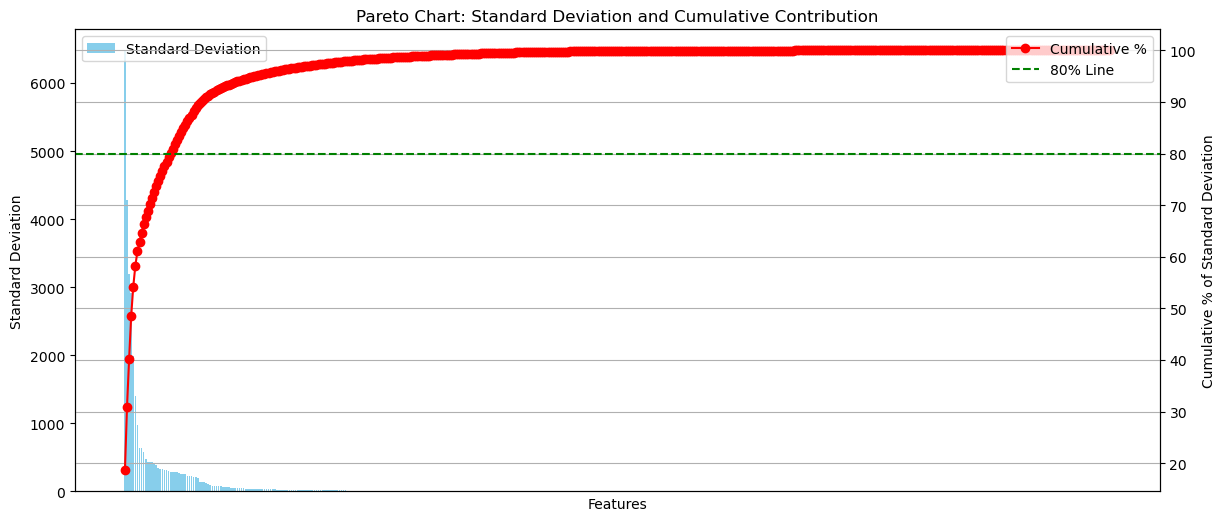

In [49]:
import matplotlib.pyplot as plt

# First, sort the stds in descending order (important!)
sorted_std = std_per_column.sort_values(ascending=False)

# Calculate cumulative sum and cumulative % (again after sorting)
cumulative_std = sorted_std.cumsum()
cumulative_std_percent = 100 * cumulative_std / cumulative_std.iloc[-1]

# Create plot
fig, ax1 = plt.subplots(figsize=(14,6))

# Bar chart for individual stds
ax1.bar(sorted_std.index, sorted_std.values, color='skyblue', label='Standard Deviation')

# Line chart for cumulative % on second y-axis
ax2 = ax1.twinx()
ax2.plot(sorted_std.index, cumulative_std_percent.values, color='red', marker='o', label='Cumulative %')

# Decorations
ax1.set_xlabel('Features')
ax1.set_ylabel('Standard Deviation')
ax2.set_ylabel('Cumulative % of Standard Deviation')
ax2.axhline(y=80, color='green', linestyle='--', label='80% Line')  # Show the 80% horizontal line
ax1.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)  # Hide x labels to avoid clutter
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Pareto Chart: Standard Deviation and Cumulative Contribution')
plt.grid(axis='y')
plt.show()


In [50]:
# Find features up to 80% point
top_features = cumulative_std_percent[cumulative_std_percent <= 80].index.tolist()

# Display them nicely
top_features_table = pd.DataFrame({
    'Feature': top_features,
    'Standard Deviation': sorted_std.loc[top_features],
    'Cumulative Std %': cumulative_std_percent.loc[top_features]
})

print("\n📋 Top Features Contributing to 80% of Standard Deviation:")
print(top_features_table)



📋 Top Features Contributing to 80% of Standard Deviation:
         Feature  Standard Deviation  Cumulative Std %
col_163  col_163         6464.728110         18.618044
col_162  col_162         4277.461541         30.936887
col_298  col_298         3194.624832         40.137222
col_25    col_25         2913.666613         48.528414
col_297  col_297         1983.591939         54.241045
col_24    col_24         1399.065222         58.270272
col_160  col_160          969.962358         61.063708
col_22    col_22          636.844802         62.897784
col_205  col_205          631.548641         64.716608
col_161  col_161          573.556392         66.368417
col_295  col_295          469.611566         67.720871
col_4      col_4          431.115520         68.962459
col_159  col_159          428.535182         70.196616
col_226  col_226          426.880885         71.426008
col_141  col_141          401.389886         72.581988
col_91    col_91          395.433166         73.720813
col_68

In [51]:
# Step 1: Check missing values in X_train
missing_counts = X_train.isnull().sum()

# Step 2: Separate features with and without missing values
missing_features = missing_counts[missing_counts > 0]
non_missing_features = missing_counts[missing_counts == 0]

# Step 3: Calculate percentage of missing values for features with missingness
missing_percentages = (missing_features / X_train.shape[0]) * 100

# Step 4: Create missing summary table
missing_summary = pd.DataFrame({
    'Missing Values': missing_features,
    'Missing Percentage (%)': missing_percentages
}).sort_values(by='Missing Percentage (%)', ascending=False)

# Step 5: Display results
print(f"\n🔎 Number of features with missing values: {missing_features.shape[0]}")
print(f"✅ Number of features without missing values: {non_missing_features.shape[0]}")
print("\n📋 Missing Values Summary (Training Set):")
print(missing_summary)



🔎 Number of features with missing values: 390
✅ Number of features without missing values: 84

📋 Missing Values Summary (Training Set):
         Missing Values  Missing Percentage (%)
col_158            1136               90.662410
col_293            1136               90.662410
col_159            1136               90.662410
col_294            1136               90.662410
col_221            1073               85.634477
col_359            1073               85.634477
col_493            1073               85.634477
col_86             1073               85.634477
col_247             831               66.320830
col_110             831               66.320830
col_111             831               66.320830
col_517             831               66.320830
col_518             831               66.320830
col_519             831               66.320830
col_383             831               66.320830
col_384             831               66.320830
col_112             831               66.320830

In [52]:
# Step 1: Calculate the total missing values across all features
total_missing_values = missing_summary['Missing Values'].sum()

# Step 2: Calculate cumulative missing values feature by feature
missing_summary['Cumulative Missing Values'] = missing_summary['Missing Values'].cumsum()

# Step 3: Calculate cumulative missing percentage
missing_summary['Cumulative Missing %'] = (missing_summary['Cumulative Missing Values'] / total_missing_values) * 100

# Step 4: Display the updated summary
pd.set_option('display.max_rows', None)  # So you see the full table if needed
print(missing_summary)

# Optional Step 5: Identify at what feature index we cross 80% cumulative missingness
cross_80_percent = (missing_summary['Cumulative Missing %'] >= 80).idxmax()

print(f"\n🚀 Feature where cumulative missingness crosses 80%: {cross_80_percent}")


         Missing Values  Missing Percentage (%)  Cumulative Missing Values  \
col_158            1136               90.662410                       1136   
col_293            1136               90.662410                       2272   
col_159            1136               90.662410                       3408   
col_294            1136               90.662410                       4544   
col_221            1073               85.634477                       5617   
col_359            1073               85.634477                       6690   
col_493            1073               85.634477                       7763   
col_86             1073               85.634477                       8836   
col_247             831               66.320830                       9667   
col_110             831               66.320830                      10498   
col_111             831               66.320830                      11329   
col_517             831               66.320830                 

In [53]:
# Step 1: Missing values in the full dataset (before split)
full_missing = merged_data.isna().sum()
full_incomplete_cols = full_missing[full_missing > 0].index.tolist()

# Step 2: Missing values in the training set (after split)
train_missing = train_data.isna().sum()
train_complete_cols = train_missing[train_missing == 0].index.tolist()

# Step 3: Find columns that were incomplete before but now look complete
newly_clean_in_train = [col for col in train_complete_cols if col in full_incomplete_cols]

print(f"Columns that were incomplete before but now clean in training set:")
print(newly_clean_in_train)

# Step 4: Check their missingness in the test set
test_missing = test_data[newly_clean_in_train].isna().sum()

print("\nMissing values for these columns in the TEST set:")
print(test_missing)


Columns that were incomplete before but now clean in training set:
['col_33', 'col_34', 'col_35', 'col_36', 'col_37', 'col_38', 'col_39', 'col_40', 'col_171', 'col_172', 'col_173', 'col_174', 'col_175', 'col_176', 'col_177', 'col_178', 'col_306', 'col_307', 'col_308', 'col_309', 'col_310', 'col_311', 'col_312', 'col_313', 'col_442', 'col_443', 'col_444', 'col_445', 'col_446', 'col_447', 'col_448', 'col_449']

Missing values for these columns in the TEST set:
col_33     1
col_34     1
col_35     1
col_36     1
col_37     1
col_38     1
col_39     1
col_40     1
col_171    1
col_172    1
col_173    1
col_174    1
col_175    1
col_176    1
col_177    1
col_178    1
col_306    1
col_307    1
col_308    1
col_309    1
col_310    1
col_311    1
col_312    1
col_313    1
col_442    1
col_443    1
col_444    1
col_445    1
col_446    1
col_447    1
col_448    1
col_449    1
dtype: int64


In [54]:
# Step 1: Identify features with more than 60% missing values
features_above_60_missing = missing_summary[
    missing_summary['Missing Percentage (%)'] > 60
]

# Step 2: Calculate number and percentage
num_features_above_60 = features_above_60_missing.shape[0]
total_features = X_train.shape[1]
percent_features_above_60 = (num_features_above_60 / total_features) * 100

# Step 3: Display results
print(f"🔍 Number of features with >60% missing values: {num_features_above_60}")
print(f"📊 Percentage of all features: {percent_features_above_60:.2f}%")



🔍 Number of features with >60% missing values: 24
📊 Percentage of all features: 5.06%


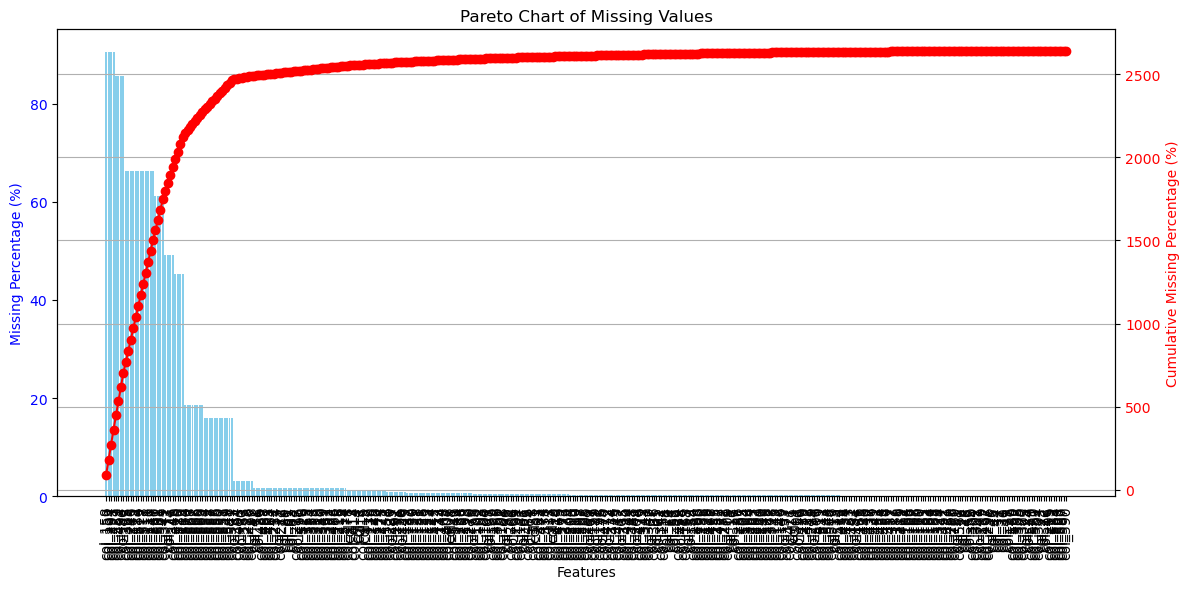

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Focus on features with missingness
missing_features_only = missing_summary[missing_summary['Missing Values'] > 0]

# Step 2: Sort by missing percentage
missing_features_sorted = missing_features_only.sort_values(by='Missing Percentage (%)', ascending=False)

# Step 3: Calculate cumulative missing percentage
missing_features_sorted['Cumulative Missing %'] = missing_features_sorted['Missing Percentage (%)'].cumsum()

# Step 4: Plot
fig, ax1 = plt.subplots(figsize=(12,6))

# Bar chart for missing percentage
ax1.bar(missing_features_sorted.index, missing_features_sorted['Missing Percentage (%)'], color='skyblue')
ax1.set_ylabel('Missing Percentage (%)', color='blue')
ax1.set_xlabel('Features')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(np.arange(len(missing_features_sorted.index)))
ax1.set_xticklabels(missing_features_sorted.index, rotation=90)

# Line chart for cumulative missing percentage
ax2 = ax1.twinx()
ax2.plot(missing_features_sorted.index, missing_features_sorted['Cumulative Missing %'], color='red', marker='o')
ax2.set_ylabel('Cumulative Missing Percentage (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Pareto Chart of Missing Values')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


NameError: name 'features_to_drop' is not defined

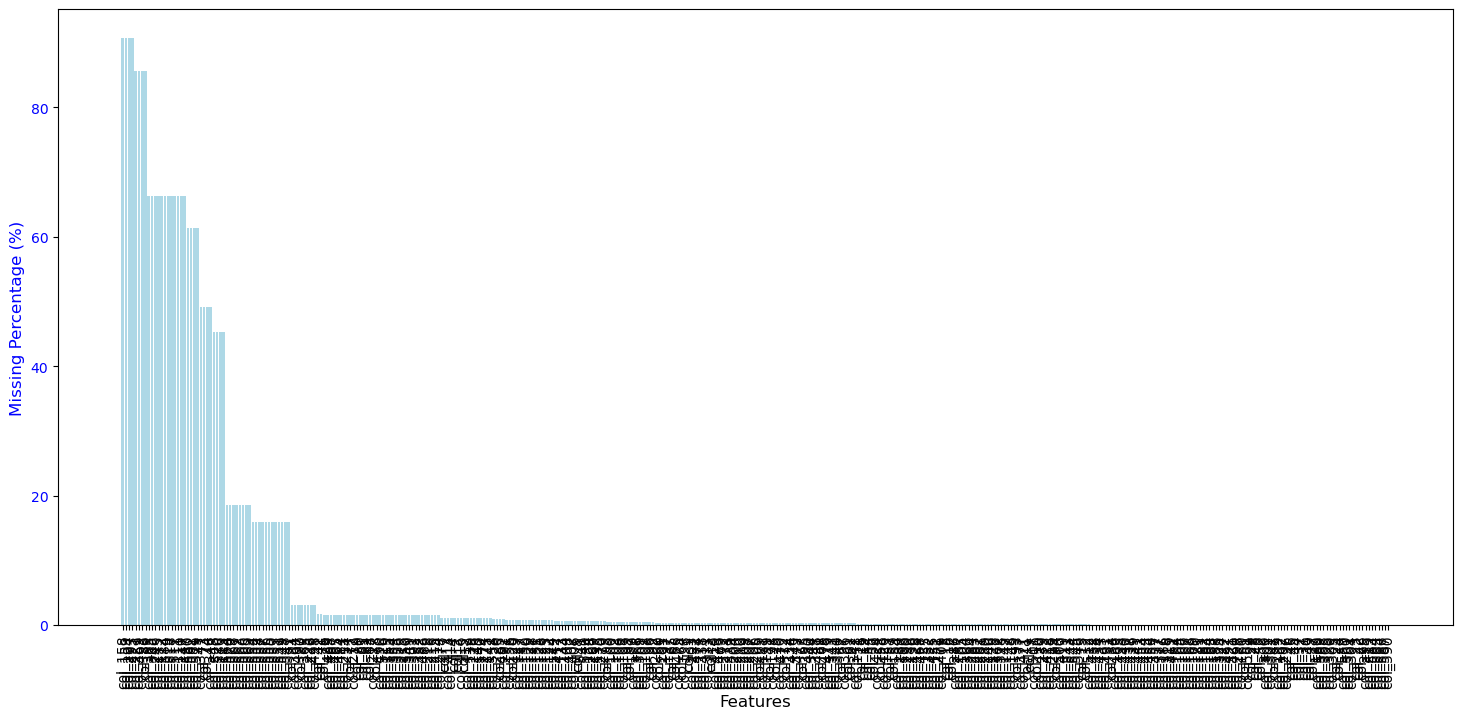

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you already have:
# - missing_summary (DataFrame with Missing Percentage)
# - features_to_drop (list of 24 features)

# Sort features
missing_summary_sorted = missing_summary.sort_values(by='Missing Percentage (%)', ascending=False)

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(18, 8))

# Bar plot of all features
bars = ax1.bar(missing_summary_sorted.index, 
               missing_summary_sorted['Missing Percentage (%)'], 
               color='lightblue')

ax1.set_xlabel('Features', fontsize=12)
ax1.set_ylabel('Missing Percentage (%)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
plt.xticks(rotation=90)

# Highlight bars that are in the 24 features
for bar, feature in zip(bars, missing_summary_sorted.index):
    if feature in features_to_drop:
        bar.set_color('red')  # highlight in red

# Secondary y-axis for cumulative %
ax2 = ax1.twinx()
cumulative = missing_summary_sorted['Missing Percentage (%)'].cumsum()
ax2.plot(missing_summary_sorted.index, cumulative, color='red', marker='o', markersize=2)
ax2.set_ylabel('Cumulative Missing Percentage (%)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# 60% Threshold line
ax1.axhline(y=60, color='green', linestyle='--', label='60% Missing Threshold')

# Title and Legend
plt.title('Pareto Chart of Missing Values (All Features)', fontsize=14)
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [57]:
# Step 1: Find features with more than 60% missing values
features_to_drop = missing_summary[missing_summary['Missing Percentage (%)'] > 60].index.tolist()

# Now features_to_drop contains the 24 features you are targeting
print(f"Number of features to drop: {len(features_to_drop)}")
print(features_to_drop)


Number of features to drop: 24
['col_158', 'col_293', 'col_159', 'col_294', 'col_221', 'col_359', 'col_493', 'col_86', 'col_247', 'col_110', 'col_111', 'col_517', 'col_518', 'col_519', 'col_383', 'col_384', 'col_112', 'col_245', 'col_246', 'col_385', 'col_580', 'col_582', 'col_581', 'col_579']


In [58]:
# Step 1: Drop features with >60% missing values ONLY from training set
X_train_reduced = X_train.drop(columns=features_to_drop)

# Step 2: Print shape to confirm
print(f"Shape of X_train after dropping: {X_train_reduced.shape}")

# Optional: Save list of dropped features
dropped_features_list = features_to_drop


Shape of X_train after dropping: (1253, 450)


In [59]:
# Step 1: Calculate the correlation matrix
corr_matrix = X_train_reduced.corr()

# Step 2: Remove self-correlations (diagonal = 1)
corr_matrix_no_diag = corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))

# Step 3: Flatten the correlation matrix
corr_pairs = corr_matrix_no_diag.stack().reset_index()
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Step 4: Take the absolute value of correlations
corr_pairs['Abs Correlation'] = corr_pairs['Correlation'].abs()

# Step 5: Sort by absolute correlation (strongest to weakest)
corr_pairs_sorted = corr_pairs.sort_values(by='Abs Correlation', ascending=False)

# Step 6: See top 20 most strongly correlated feature pairs
print("\n🔍 Top 20 Most Strongly Correlated Feature Pairs:")
print(corr_pairs_sorted.head(20))



🔍 Top 20 Most Strongly Correlated Feature Pairs:
       Feature 1 Feature 2  Correlation  Abs Correlation
167263   col_479   col_343          1.0              1.0
123819   col_343   col_479          1.0              1.0
83419    col_210   col_479          1.0              1.0
167174   col_479   col_210          1.0              1.0
30900     col_75   col_479          1.0              1.0
167058   col_479    col_75          1.0              1.0
167268   col_479   col_348          1.0              1.0
167171   col_479   col_207          1.0              1.0
82076    col_207   col_479          1.0              1.0
123635   col_343   col_210          1.0              1.0
126060   col_348   col_479          1.0              1.0
83323    col_210   col_343          1.0              1.0
30804     col_75   col_343          1.0              1.0
125965   col_348   col_343          1.0              1.0
123728   col_343   col_348          1.0              1.0
123519   col_343    col_75          1.

In [60]:
import pandas as pd

# Set option to display all columns
pd.set_option('display.max_columns', None)

# Now print the columns
print(test_data.columns.tolist())

# If you want to see a few rows too (optional)
print(test_data.head())

# (Optional) After viewing, you can reset back to default:
# pd.reset_option('display.max_columns')


['col_1', 'col_2', 'col_3', 'col_4', 'col_5', 'col_6', 'col_7', 'col_8', 'col_9', 'col_10', 'col_11', 'col_12', 'col_13', 'col_14', 'col_15', 'col_16', 'col_17', 'col_18', 'col_19', 'col_20', 'col_21', 'col_22', 'col_23', 'col_24', 'col_25', 'col_26', 'col_27', 'col_28', 'col_29', 'col_30', 'col_31', 'col_32', 'col_33', 'col_34', 'col_35', 'col_36', 'col_37', 'col_38', 'col_39', 'col_40', 'col_41', 'col_42', 'col_43', 'col_44', 'col_45', 'col_46', 'col_47', 'col_48', 'col_49', 'col_50', 'col_51', 'col_52', 'col_53', 'col_54', 'col_55', 'col_56', 'col_57', 'col_58', 'col_59', 'col_60', 'col_61', 'col_62', 'col_63', 'col_64', 'col_65', 'col_66', 'col_67', 'col_68', 'col_69', 'col_70', 'col_71', 'col_72', 'col_73', 'col_74', 'col_75', 'col_76', 'col_77', 'col_78', 'col_79', 'col_80', 'col_81', 'col_82', 'col_83', 'col_84', 'col_85', 'col_86', 'col_87', 'col_88', 'col_89', 'col_90', 'col_91', 'col_92', 'col_93', 'col_94', 'col_95', 'col_96', 'col_97', 'col_98', 'col_99', 'col_100', 'col_10

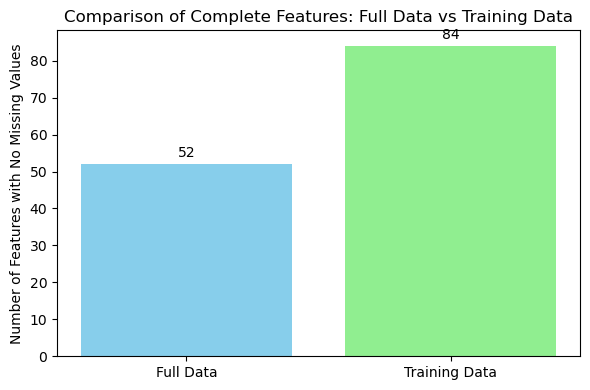

In [61]:
import matplotlib.pyplot as plt

# Step 1: Define the numbers
full_data_complete_features = 52  # based on your memory from earlier
train_data_complete_features = 84  # based on what we just computed

# Step 2: Prepare for plotting
datasets = ['Full Data', 'Training Data']
complete_counts = [full_data_complete_features, train_data_complete_features]

# Step 3: Plot
fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(datasets, complete_counts, color=['skyblue', 'lightgreen'])

# Add labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom')

# Labels and title
ax.set_ylabel('Number of Features with No Missing Values')
ax.set_title('Comparison of Complete Features: Full Data vs Training Data')

plt.tight_layout()
plt.show()


Mean Missing Percentage: 6.77%
Standard Deviation of Missing Percentage: 18.70%
3σ Threshold: 62.87%
4σ Threshold: 81.57%

🔎 Number of features above 3σ threshold: 20
🔎 Number of features above 4σ threshold: 8


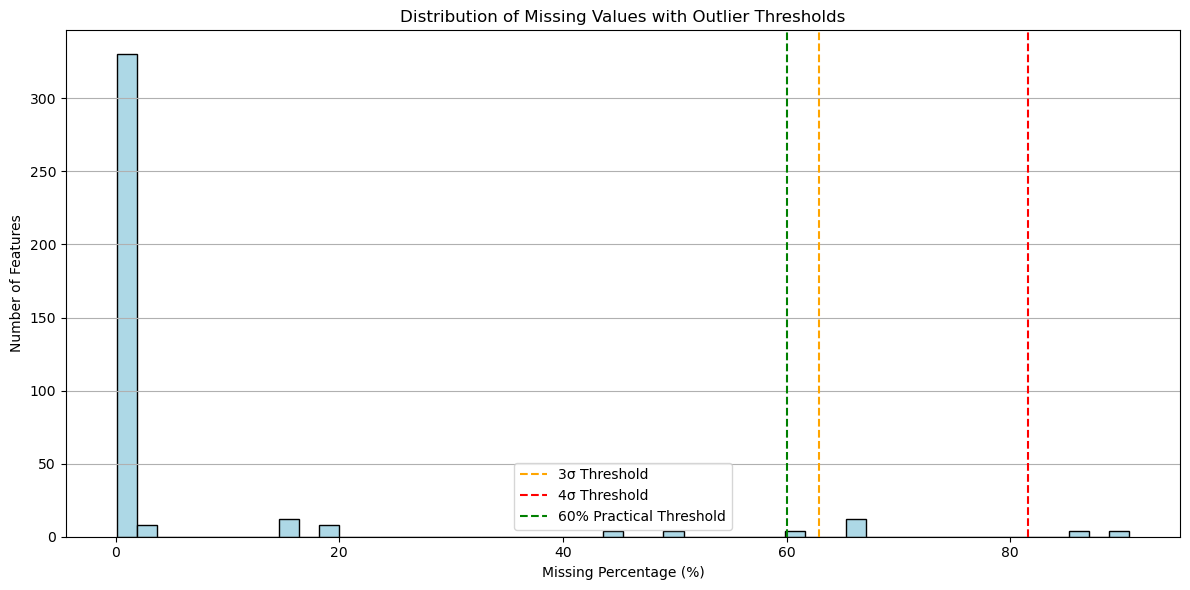

In [62]:
# Outlier analysis on missing percentages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming you have 'missing_summary' from before
missing_percentages = missing_summary['Missing Percentage (%)']

# Step 1: Calculate mean and standard deviation
mean_missing = missing_percentages.mean()
std_missing = missing_percentages.std()

# Step 2: Define thresholds
threshold_3s = mean_missing + 3 * std_missing
threshold_4s = mean_missing + 4 * std_missing

print(f"Mean Missing Percentage: {mean_missing:.2f}%")
print(f"Standard Deviation of Missing Percentage: {std_missing:.2f}%")
print(f"3σ Threshold: {threshold_3s:.2f}%")
print(f"4σ Threshold: {threshold_4s:.2f}%")

# Step 3: Identify outliers
outliers_3s = missing_summary[missing_percentages > threshold_3s]
outliers_4s = missing_summary[missing_percentages > threshold_4s]

print(f"\n🔎 Number of features above 3σ threshold: {outliers_3s.shape[0]}")
print(f"🔎 Number of features above 4σ threshold: {outliers_4s.shape[0]}")

# Step 4: Plotting
plt.figure(figsize=(12,6))
plt.hist(missing_percentages, bins=50, color='lightblue', edgecolor='black')
plt.axvline(threshold_3s, color='orange', linestyle='--', label='3σ Threshold')
plt.axvline(threshold_4s, color='red', linestyle='--', label='4σ Threshold')
plt.axvline(60, color='green', linestyle='--', label='60% Practical Threshold')
plt.title('Distribution of Missing Values with Outlier Thresholds')
plt.xlabel('Missing Percentage (%)')
plt.ylabel('Number of Features')
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [63]:
import numpy as np

# Assume missing_percentages is your Series of missing percentages

# Step 1: Create the histogram (but do not plot yet)
counts, bin_edges = np.histogram(missing_percentages, bins=30)  
# (or bins=20 if you want fewer groups)

# Step 2: View the counts and the bin edges
for count, left_edge, right_edge in zip(counts, bin_edges[:-1], bin_edges[1:]):
    print(f"Missing % between {left_edge:.1f}% and {right_edge:.1f}%: {count} features")


Missing % between 0.1% and 3.1%: 338 features
Missing % between 3.1% and 6.1%: 0 features
Missing % between 6.1% and 9.1%: 0 features
Missing % between 9.1% and 12.2%: 0 features
Missing % between 12.2% and 15.2%: 0 features
Missing % between 15.2% and 18.2%: 12 features
Missing % between 18.2% and 21.2%: 8 features
Missing % between 21.2% and 24.2%: 0 features
Missing % between 24.2% and 27.3%: 0 features
Missing % between 27.3% and 30.3%: 0 features
Missing % between 30.3% and 33.3%: 0 features
Missing % between 33.3% and 36.3%: 0 features
Missing % between 36.3% and 39.3%: 0 features
Missing % between 39.3% and 42.4%: 0 features
Missing % between 42.4% and 45.4%: 4 features
Missing % between 45.4% and 48.4%: 0 features
Missing % between 48.4% and 51.4%: 4 features
Missing % between 51.4% and 54.4%: 0 features
Missing % between 54.4% and 57.4%: 0 features
Missing % between 57.4% and 60.5%: 0 features
Missing % between 60.5% and 63.5%: 4 features
Missing % between 63.5% and 66.5%: 12 

In [77]:
from sklearn.preprocessing import RobustScaler

# Initialize the RobustScaler
scaler = RobustScaler()

# Fit the scaler on the training data (X_train_reduced)
X_train_scaled = scaler.fit_transform(X_train_reduced)

# Convert the result back to a DataFrame for better readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_reduced.columns)

# Display the first few rows of the scaled data
print(X_train_scaled.head())



      col_1     col_2     col_3     col_4     col_5     col_7     col_8  \
0  0.705503 -0.107758 -0.429691 -0.162177 -1.042097  0.650628 -0.592593   
1  0.664220 -0.126601  0.445043  0.278867  0.860846  0.713068 -0.888889   
2  0.067609  0.281113  0.003011 -0.793694  0.190996  0.757930 -0.481481   
3 -1.211822  0.815310  0.621799  0.909303  1.326447 -0.745294  0.629630   
4 -0.318064 -0.392875 -2.259260 -0.766396  0.226467  0.749731  1.074074   

      col_9    col_10    col_11    col_12    col_13    col_15    col_16  \
0 -0.593355 -0.722513 -0.088496  0.610687  0.888062 -1.561302 -1.021614   
1  0.593355  0.413613 -1.132743 -0.458015  0.196577  0.356375 -0.538182   
2 -0.857277  0.041885  0.424779  0.129771 -0.383394  0.354189  0.255409   
3  1.229761 -0.785340  0.504425  1.351145 -0.982732 -0.100104 -0.993074   
4 -0.204024 -0.434555  0.017699  0.870229 -0.143113  0.940604  1.621191   

     col_17    col_18    col_19    col_20    col_21    col_22    col_23  \
0  0.709715  1.190476  

In [78]:
print("Shape of data before imputation:", X_train_reduced.shape)


Shape of data before imputation: (1253, 450)


In [84]:
from sklearn.impute import SimpleImputer

# Step 1: Initialize the imputer with the 'mean' strategy
mean_imputer = SimpleImputer(strategy='mean')

# Step 2: Apply the imputer to the training data
X_train_imputed_mean = mean_imputer.fit_transform(X_train_reduced)

# Step 3: Convert the result back to DataFrame for easier inspection
X_train_imputed_mean = pd.DataFrame(X_train_imputed_mean, columns=X_train_reduced.columns)

# Step 4: Check the shape of the data before and after imputation
print("Before imputation:")
print(X_train_reduced.isnull().sum())  # Showing number of missing values before imputation

print("\nAfter imputation:")
print(X_train_imputed_mean.isnull().sum())  # Showing number of missing values after imputation


Before imputation:
col_1        5
col_2        5
col_3       13
col_4       13
col_5       13
col_7       13
col_8        8
col_9        2
col_10       2
col_11       2
col_12       2
col_13       2
col_15       3
col_16       3
col_17       3
col_18       3
col_19       3
col_20      10
col_21       0
col_22       1
col_23       1
col_24       1
col_25       1
col_26       1
col_27       1
col_28       1
col_29       1
col_30       1
col_31       1
col_32       1
col_33       0
col_34       0
col_35       0
col_36       0
col_37       0
col_38       0
col_39       0
col_40       0
col_41      21
col_42      21
col_44       1
col_45       1
col_46       1
col_47       1
col_48       1
col_49       1
col_51       1
col_52       1
col_54       3
col_55       3
col_56       3
col_57       3
col_58       3
col_59       3
col_60       5
col_61       4
col_62       4
col_63       4
col_64       5
col_65       5
col_66       5
col_67       4
col_68       4
col_69       4
col_71       4
col_72

In [85]:

# Initialize the RobustScaler
scaler = RobustScaler()

# Fit the scaler on the training data (X_train_reduced)
X_train_imputed_mean_scaled = scaler.fit_transform(X_train_imputed_mean)

# Convert the result back to a DataFrame for better readability
X_train_imputed_mean_scaled  = pd.DataFrame(X_train_scaled, columns=X_train_imputed_mean.columns)


Shape before imputation: (1253, 450)
Shape after KNN imputation: (1253, 450)


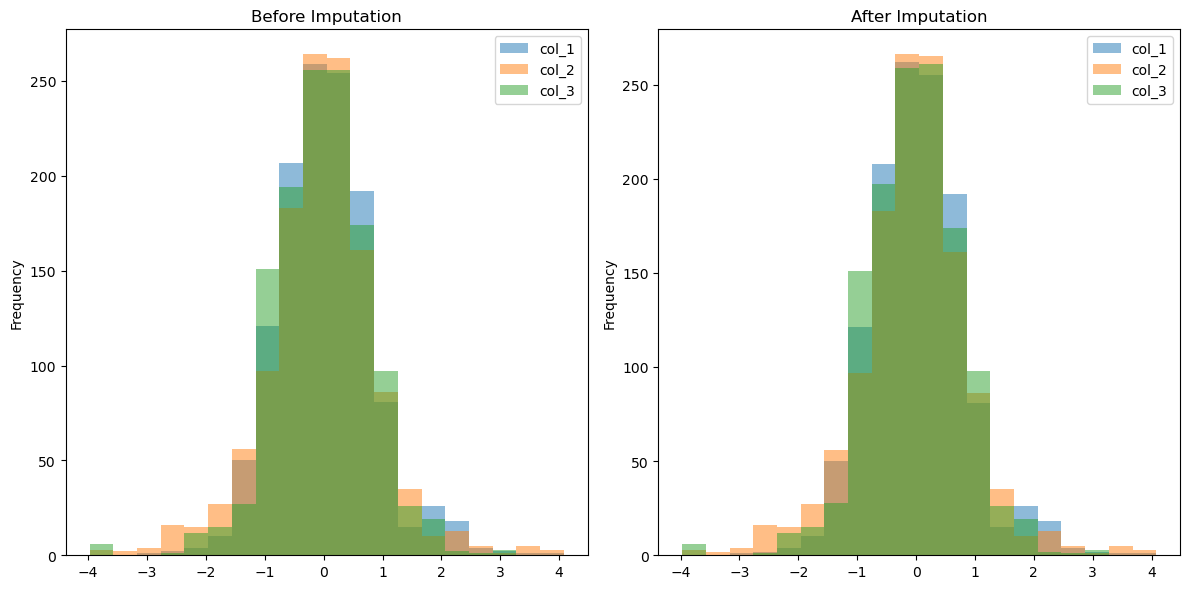

In [81]:
from sklearn.impute import KNNImputer

# Initialize KNNImputer with k=5 neighbors
knn_imputer = KNNImputer(n_neighbors=5)

# Fit the imputer on the scaled training data and transform it
X_train_knn_imputed = knn_imputer.fit_transform(X_train_scaled)

# Convert back to DataFrame for readability, preserving column names
X_train_knn_imputed = pd.DataFrame(X_train_knn_imputed, columns=X_train_scaled.columns)

# Check the shape to confirm
print(f"Shape before imputation: {X_train_scaled.shape}")
print(f"Shape after KNN imputation: {X_train_knn_imputed.shape}")

# Plot the histograms of the first 3 columns before and after imputation
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Before imputation
X_train_scaled.iloc[:, :3].plot(kind='hist', bins=20, alpha=0.5, ax=axes[0], title="Before Imputation")

# After imputation
X_train_knn_imputed.iloc[:, :3].plot(kind='hist', bins=20, alpha=0.5, ax=axes[1], title="After Imputation")

plt.tight_layout()
plt.show()


In [82]:
import numpy as np
import pandas as pd

# 1. Calculate variance and missing percentage for each feature
variance = X_train_reduced.var()
missing_percentage = X_train_reduced.isnull().mean() * 100

# 2. Define thresholds for variance (adjust as needed)
low_var_thresh = variance.quantile(0.25)
high_var_thresh = variance.quantile(0.75)

# 3. Group columns by variance level
low_var_cols = variance[variance <= low_var_thresh].index.tolist()
medium_var_cols = variance[(variance > low_var_thresh) & (variance < high_var_thresh)].index.tolist()
high_var_cols = variance[variance >= high_var_thresh].index.tolist()

# 4. Group columns by missingness level
low_missing_cols = missing_percentage[missing_percentage < 10].index.tolist()
medium_missing_cols = missing_percentage[(missing_percentage >= 10) & (missing_percentage <= 60)].index.tolist()
high_missing_cols = missing_percentage[missing_percentage > 60].index.tolist()

# 5. Select some representative columns from each group
# Here you can pick some from variance groups that overlap with missingness groups
# For example, pick 1-2 columns with low variance and low missingness, etc.

selected_cols = []

# Sample selection, customize as needed:
selected_cols += low_var_cols[:2]
selected_cols += medium_var_cols[:2]
selected_cols += high_var_cols[:2]

# To avoid duplicates
selected_cols = list(set(selected_cols))

print("Representative columns selected:", selected_cols)


Representative columns selected: ['col_1', 'col_7', 'col_8', 'col_2', 'col_10', 'col_9']


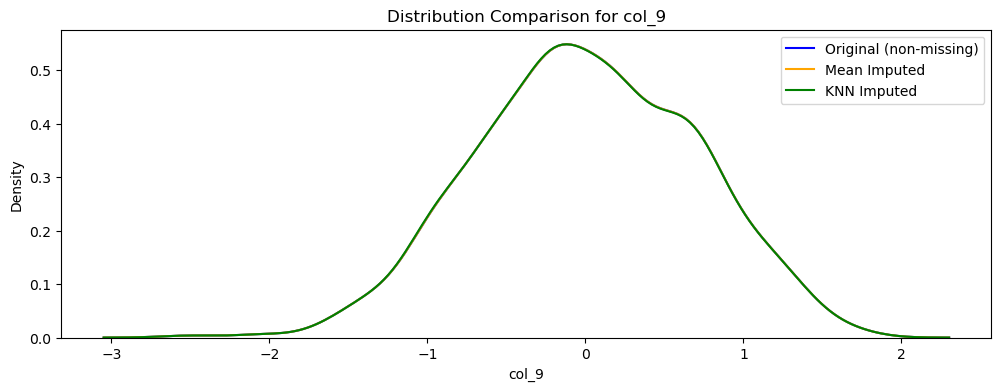

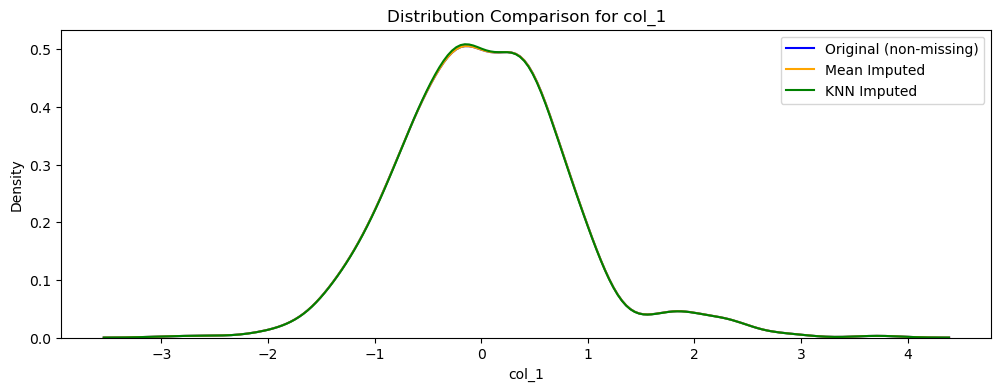

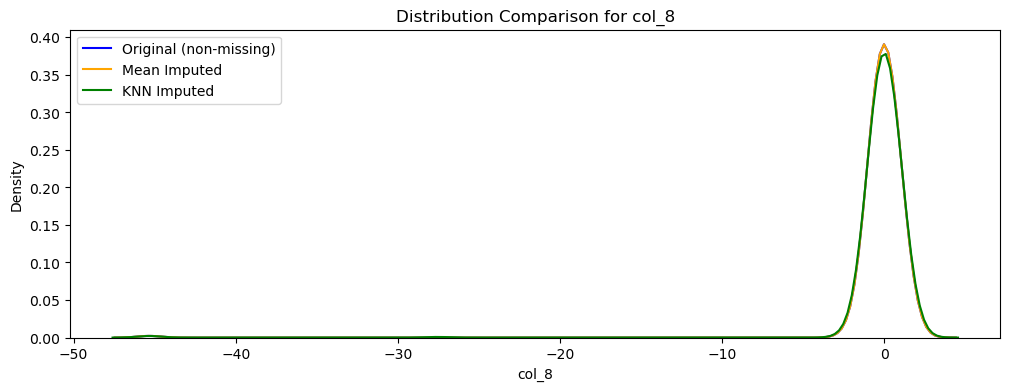

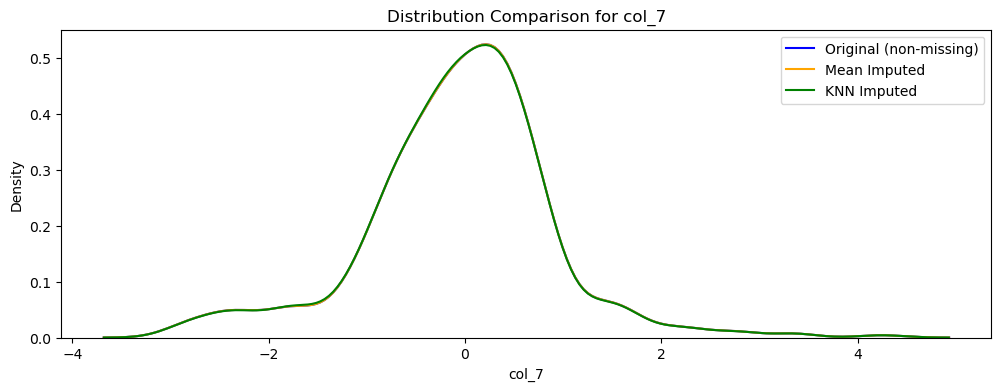

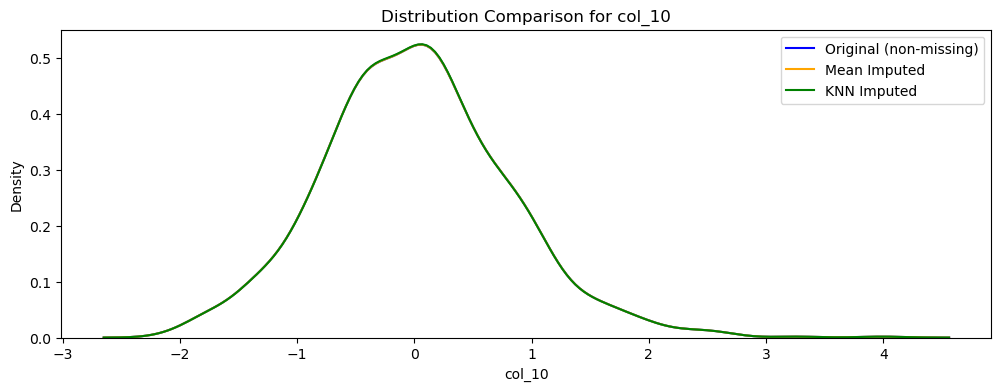

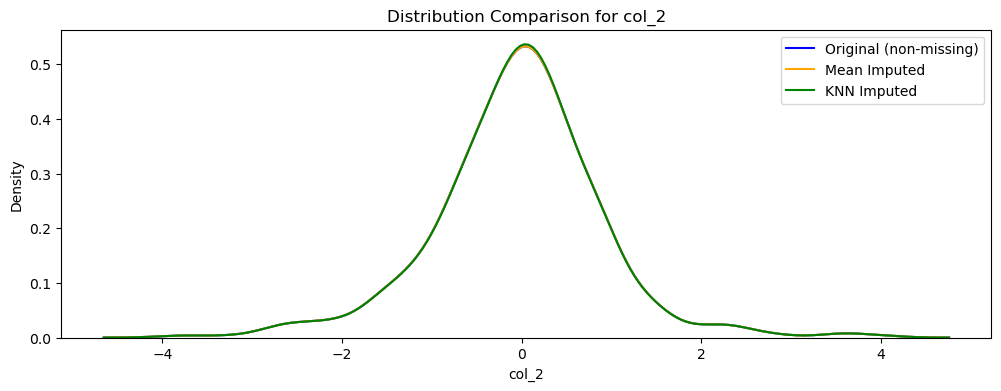

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use your actual DataFrame names here
original_data = X_train_scaled.copy()
mean_imputed_data = X_train_imputed_mean_scaled.copy()   
knn_imputed_data = X_train_knn_imputed.copy()     
selected_cols = ['col_9', 'col_1', 'col_8', 'col_7', 'col_10', 'col_2']

for col in selected_cols:
    plt.figure(figsize=(12, 4))
    
    sns.kdeplot(original_data[col].dropna(), label='Original (non-missing)', color='blue')
    sns.kdeplot(mean_imputed_data[col], label='Mean Imputed', color='orange')
    sns.kdeplot(knn_imputed_data[col], label='KNN Imputed', color='green')
    
    plt.title(f'Distribution Comparison for {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()
    plt.show()


In [83]:
import numpy as np

# Columns to test on
test_cols = ['col_9', 'col_1', 'col_8', 'col_7', 'col_10', 'col_2']

# Copy original scaled data
X_train_simulated = X_train_scaled.copy()

# Dictionary to keep track of masked indices and original values
masked_info = {}

# For reproducibility
np.random.seed(42)

for col in test_cols:
    # Get indices of non-missing values
    non_missing_indices = X_train_simulated[col].dropna().index
    
    # Number of values to mask (~10%)
    n_mask = int(0.1 * len(non_missing_indices))
    
    # Randomly choose indices to mask
    mask_indices = np.random.choice(non_missing_indices, size=n_mask, replace=False)
    
    # Store original values before masking
    original_values = X_train_simulated.loc[mask_indices, col].copy()
    
    # Mask values by setting to NaN
    X_train_simulated.loc[mask_indices, col] = np.nan
    
    # Save mask info
    masked_info[col] = {'indices': mask_indices, 'original_values': original_values}

print("Simulated missingness created with ~10% values masked in selected columns.")


Simulated missingness created with ~10% values masked in selected columns.


In [85]:
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error
import pandas as pd

# Use these variables from your environment
# X_train_scaled: original scaled training data (before simulated missingness)
# X_train_simulated: training data with ~10% simulated missingness in selected columns (test_cols)
# masked_info: dictionary with masked indices and original values for each test column
# test_cols: list of columns where missingness was simulated

# Step 1: Mean Imputation on simulated data
mean_imputed_data = X_train_simulated.copy()
for col in test_cols:
    mean_value = X_train_scaled[col].mean()  # Use original mean before masking
    mean_imputed_data[col].fillna(mean_value, inplace=True)

# Step 2: KNN Imputation on simulated data
knn_imputer = KNNImputer(n_neighbors=5)
knn_imputed_array = knn_imputer.fit_transform(mean_imputed_data[test_cols])
knn_imputed_data = mean_imputed_data.copy()
knn_imputed_data[test_cols] = knn_imputed_array

# Step 3: Calculate MSE for each method on masked positions
def calculate_mse(imputed_data, original_scaled_data, masked_info):
    mse_dict = {}
    for col in test_cols:
        indices = masked_info[col]['indices']
        true_vals = original_scaled_data.loc[indices, col]
        imputed_vals = imputed_data.loc[indices, col]
        mse = mean_squared_error(true_vals, imputed_vals)
        mse_dict[col] = mse
    return mse_dict

mse_mean = calculate_mse(mean_imputed_data, X_train_scaled, masked_info)
mse_knn = calculate_mse(knn_imputed_data, X_train_scaled, masked_info)

# Step 4: Show results
print("Mean Imputation MSE per column:")
print(pd.Series(mse_mean))

print("\nKNN Imputation MSE per column:")
print(pd.Series(mse_knn))


Mean Imputation MSE per column:
col_9     0.479946
col_1     0.735175
col_8     0.540747
col_7     1.016339
col_10    0.639207
col_2     0.787132
dtype: float64

KNN Imputation MSE per column:
col_9     0.479946
col_1     0.735175
col_8     0.540747
col_7     1.016339
col_10    0.639207
col_2     0.787132
dtype: float64


/var/folders/c7/47_sd8tn00398pc3xmjbblh80000gn/T/ipykernel_1729/696842335.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mean_imputed_data[col].fillna(mean_value, inplace=True)
